In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

In [2]:
from UnifiedMomentumModel.Momentum import UnifiedMomentum

In [3]:
%matplotlib inline
plt.rcParams["text.usetex"] = True

In [4]:
rho, uinf, D = 1, 1, 1
dt = 0.05

In [5]:
def calc_an(df, ud_key, uinf_key):
    return 1 - (df[ud_key] / df[uinf_key])

def calc_ct(df, ud_key, uinf_key):
    return np.sign(df[ud_key]) * df["Local Thrust Coefficient"] * ((df[ud_key])**2 / (df[uinf_key])**2)

def calc_cp(df, uinf_key = "UInf_Ground"):  # power in PadeOps and UMM is calculated in the turbine frame of reference!
    return df.Power / (0.5 * rho * math.pi * (D/2)**2 * (df[uinf_key])**3)

# UMM Data

In [6]:
def get_tilt_vals(Ap, f, dt):
    T = 1 / f
    omega = 2 * np.pi * f
    phi = np.array([Ap * np.sin(omega * t) for t in np.arange(0, 2*T, dt)])
    phases = np.linspace(0, 1, num = int(len(phi) / 2))
    return np.deg2rad(phi), [phases[i % len(phases)] for i in range(len(phi))]

def get_uturb_vals(As, f, dt):
    T = 1 / f
    omega = 2 * np.pi * f
    uturb = np.array([As * np.cos(omega * t) for t in np.arange(0, 2*T, dt)])
    dx = np.array([(As / omega) * np.sin(omega * t) for t in np.arange(0, 2*T, dt)])
    return uturb, dx

In [7]:
Ap_vals = np.array([i * 2 for i in range(1, 10)])
As_vals = np.array([i * 0.1 for i in range(1, 10)])
f_vals = np.array([i * 0.2 for i in range(1, 5)])

In [8]:
Ax_vals = []
for a in As_vals:
    for f in f_vals:
        omega = (2 * np.pi * f)
        if omega != 0:
            Ax_vals.append((a, f, a / omega))
Ax_vals = np.array(Ax_vals)

In [9]:
as_vals_unzipped, f_vals_unzipped, Ax_vals_unzipped = zip(*Ax_vals)

In [10]:
sns.scatterplot(x = as_vals_unzipped, y = Ax_vals_unzipped, hue = f_vals_unzipped, palette="tab20", legend="full")
plt.axhline(0.4, color='black', linestyle='--', linewidth=2)

Error in callback <function _draw_all_if_interactive at 0x1109ae700> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmss10.tfm' in your texmf tree, but could not find it

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmss10.tfm' in your texmf tree, but could not find it

<Figure size 640x480 with 1 Axes>

In [11]:
model = UnifiedMomentum()

In [12]:
pitch_umm_vals = []
for ct in [1.33, 2]:
    umm_stationary = model(ct, yaw = 0.0, tilt = 0.0)
    umm_an_stationary = umm_stationary.an
    umm_Cp_stationary = umm_stationary.Cp
    umm_Ct_stationary = umm_stationary.Ct
    for a in Ap_vals:
        for f in f_vals:
            tilts, phases = get_tilt_vals(a, f, dt)
            for (i, tilt) in enumerate(tilts):
                p = phases[i]
                tilted_vals = model(ct, yaw = 0.0, tilt = tilt)
                vals = (ct, a, a, tilt, f, 0, tilted_vals.an, tilted_vals.an / umm_an_stationary, tilted_vals.Ct, tilted_vals.Ct / umm_Ct_stationary, tilted_vals.Cp, tilted_vals.Cp / umm_Cp_stationary, p)
                pitch_umm_vals.append(vals)
                
pitch_umm_vals = np.array(pitch_umm_vals)

In [13]:
df_umm_pitch = pd.DataFrame(pitch_umm_vals, columns=["Local Thrust Coefficient", "Amplitude", "Distance", "Tilt", "Frequency", "UTurb ", "an_Turb", "an_Turb_normalized", "Ct_Turb", "Ct_Turb_normalized", "Cp_Turb", "Cp_Turb_normalized", "Phase_Rounded"])

In [14]:
surge_umm_vals = []
for ct in [1.33, 2]:
    umm_stationary = model(ct, yaw = 0.0, tilt = 0.0)
    umm_an_stationary = umm_stationary.an
    umm_Cp_stationary = umm_stationary.Cp
    umm_Ct_stationary = umm_stationary.Ct
    for a in As_vals:
        a = np.round(a, decimals= 1)
        for f in f_vals:
            uturb, dx = get_uturb_vals(a, f, dt)
            for (i, ut) in enumerate(uturb):
                x = dx[i]
                p = np.arctan2(2 * np.pi * f * x, ut) 
                p = np.mod(p, 2*np.pi) / (2*np.pi)
                rp = np.round(p, decimals = 2)
                uinf_t = 1 - ut
                Cp = umm_Cp_stationary * (uinf_t**3)
                Ct = umm_Ct_stationary * (uinf_t**2)
                surge_umm_vals.append((ct, a, a / (2 * np.pi * f), 0, f, ut, umm_an_stationary, umm_an_stationary / umm_an_stationary, Ct, Ct / umm_Ct_stationary, Cp, Cp / umm_Cp_stationary, p))
surge_umm_vals = np.array(surge_umm_vals)

In [15]:
df_umm_surge = pd.DataFrame(surge_umm_vals, columns=["Local Thrust Coefficient", "Amplitude", "Distance", "Tilt", "Frequency", "UTurb", "an_Turb", "an_Turb_normalized", "Ct_Turb", "Ct_Turb_normalized", "Cp_Turb", "Cp_Turb_normalized", "Phase_Rounded"])

In [16]:
df_umm_surge["Movement"] = "Surge"
df_umm_pitch["Movement"] = "Pitch"
df_umm = pd.concat([df_umm_surge, df_umm_pitch], ignore_index=True)

In [17]:
df_umm["UInf_Turb"] = (uinf - df_umm["UTurb"]) * np.cos(df_umm["Tilt"])
df_umm["UDisk_Turb"] = (1 - df_umm["an_Turb"]) * df_umm["UInf_Turb"]
df_umm["UDisk_Ground"] = df_umm["UDisk_Turb"] + df_umm["UTurb"]

In [18]:
df_avg_umm = df_umm.groupby(["Frequency", "Amplitude", "Movement", "Local Thrust Coefficient"], as_index=False).agg({
    "an_Turb": "mean",
    "an_Turb_normalized": "mean",
    "Ct_Turb": "mean",
    "Ct_Turb_normalized": "mean",
    "Cp_Turb": "mean",
    "Cp_Turb_normalized": "mean",
})
df_avg_umm["stat"] = "mean"

In [19]:
df_std_umm = df_umm.groupby(["Frequency", "Amplitude", "Movement", "Local Thrust Coefficient"], as_index=False).agg({
    "an_Turb": "std",
    "an_Turb_normalized": "std",
    "Ct_Turb": "std",
    "Ct_Turb_normalized": "std",
    "Cp_Turb": "std",
    "Cp_Turb_normalized": "std",
})
df_std_umm["stat"] = "std"

In [20]:
df_stat_umm = pd.concat([df_avg_umm, df_std_umm], ignore_index=True)
df_stat_umm

,Frequency,Amplitude,Movement,Local Thrust Coefficient,an_Turb,an_Turb_normalized,Ct_Turb,Ct_Turb_normalized,Cp_Turb,Cp_Turb_normalized,stat
0,0.2,0.1,Surge,1.33,0.249143,1.000000,0.753586,1.005000,0.571466,1.015000,mean
1,0.2,0.1,Surge,2.00,0.331407,1.000000,0.898503,1.005000,0.606711,1.015000,mean
2,0.2,0.2,Surge,1.33,0.249143,1.000000,0.764833,1.020000,0.596801,1.060000,mean
3,0.2,0.2,Surge,2.00,0.331407,1.000000,0.911914,1.020000,0.633609,1.060000,mean
4,0.2,0.3,Surge,1.33,0.249143,1.000000,0.783579,1.045000,0.639028,1.135000,mean
...,...,...,...,...,...,...,...,...,...,...,...
283,0.8,14.0,Pitch,2.00,0.004112,0.012408,0.008245,0.009222,0.008215,0.013743,std
284,0.8,16.0,Pitch,1.33,0.004446,0.017844,0.012074,0.016102,0.013444,0.023879,std
285,0.8,16.0,Pitch,2.00,0.005374,0.016216,0.010830,0.012113,0.010769,0.018016,std
286,0.8,18.0,Pitch,1.33,0.005624,0.022573,0.015307,0.020414,0.016992,0.030180,std


In [21]:
label_size = 22
title_size = 24

freqs = sorted(df_avg_umm["Frequency"].unique())
freqs = np.round(freqs, decimals=2)
palette = sns.color_palette("GnBu_d", n_colors=len(freqs))

# 2) Create the FacetGrid / relplot for the UMM lines (sharing y only)
g = sns.relplot(
    data=df_stat_umm,
    x="Amplitude",
    y="Cp_Turb",
    hue="Frequency",
    style = "Local Thrust Coefficient",
    col = "stat",
    row="Movement",
    kind="scatter",
    palette=palette,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": False},
    zorder = 10,
    s = 120
)

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmss10.tfm' in your texmf tree, but could not find it

Error in callback <function _draw_all_if_interactive at 0x1109ae700> (for post_execute), with arguments args (),kwargs {}:


FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmss10.tfm' in your texmf tree, but could not find it

FileNotFoundError: Matplotlib's TeX implementation searched for a file named 'cmss10.tfm' in your texmf tree, but could not find it

<Figure size 960x800 with 4 Axes>

# LES Data

In [ ]:
df_les = pd.read_csv("/Users/sky/src/HowlandLab/data/sim_16_all_runs_data_points_11_25.csv")
df_les = df_les.dropna()
df_les = df_les[((df_les["Thrust Coefficient"] != 1.66) & ((df_les["Frequency"] > 0.1) | (df_les["Frequency"] == 0.0)) & (df_les["Frequency"] < 1))]
df_les = df_les[(((df_les["Movement"] == "Pitch") & (df_les["Amplitude"] < 20)) | ((df_les["Movement"] == "Surge") & (df_les["Amplitude"] < 1)) | (df_les["Amplitude"] == 0.0))]

In [ ]:
df_les = df_les.rename(columns={'UDisk': 'UDisk_Turb', 'Thrust Coefficient': 'Local Thrust Coefficient'}) # disk velocity in the turbine frame of reference
df_les["UDisk_Ground"] = df_les["UDisk_Turb"] + df_les["UTurb"] # disk velocity in the ground frame of reference

In [ ]:
df_les["UInf_Turb"] = (uinf - df_les["UTurb"]) * np.cos(df_les["Tilt"])
df_les["UInf_Ground"] = uinf * np.cos(df_les["Tilt"])

In [ ]:
df_les["an_Turb"] = calc_an(df_les, ud_key = "UDisk_Turb", uinf_key = "UInf_Turb")
df_les["Ct_Turb"] = calc_ct(df_les, ud_key = "UDisk_Turb", uinf_key = "UInf_Ground")
df_les["Cp_Turb"] = calc_cp(df_les, uinf_key = "UInf_Ground")

In [ ]:
df_les["Phase"] = np.arctan2(2 * np.pi * df_les["Frequency"] * df_les["DeltaX"], df_les["UTurb"]) 
df_les["Phase"] = np.mod(df_les["Phase"], 2*np.pi) / (2*np.pi)
df_les["Phase_Shifted"] = (df_les["Phase"] + 0.5) % 1
df_les["Phase_Rounded"] = np.round(df_les["Phase"], decimals = 2)

In [ ]:
df_avg_les = df_les.groupby(["Frequency", "Amplitude", "Movement", "Local Thrust Coefficient"], as_index=False).agg({
    "an_Turb": "mean",
    "Ct_Turb": "mean",
    "Cp_Turb": "mean",
    "UDisk_Turb" : "mean",
    "UDisk_Ground": "mean",
})
df_avg_les["an_Turb_normalized"] = np.nan
df_avg_les["Ct_Turb_normalized"] = np.nan
df_avg_les["Cp_Turb_normalized"] = np.nan
les_an_stationary_ct_133 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 1.33))]["an_Turb"]
les_an_stationary_ct_200 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 2.00))]["an_Turb"]

les_ct_stationary_ct_133 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 1.33))]["Ct_Turb"]
les_ct_stationary_ct_200 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 2.00))]["Ct_Turb"]

les_cp_stationary_ct_133 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 1.33))]["Cp_Turb"]
les_cp_stationary_ct_200 = df_avg_les[((df_avg_les["Movement"] == "Stationary") & (df_avg_les["Local Thrust Coefficient"] == 2.00))]["Cp_Turb"]
df_les = df_les[(df_les["Frequency"] != 0)]

In [ ]:
df_phase_avg_les = df_les.groupby(["Frequency", "Amplitude", "Movement", "Local Thrust Coefficient", "Phase_Rounded"], as_index=False).agg({
    "an_Turb": "mean",
    "Phase_Shifted": "mean",
    "UTurb" : "mean",
    "UDisk_Turb" : "mean",
    "UDisk_Ground": "mean",
    "UInf_Turb" : "mean",
})

In [ ]:
df_les["an_Turb_normalized"] = np.nan
df_les["Ct_Turb_normalized"] = np.nan
df_les["Cp_Turb_normalized"] = np.nan
df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "an_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "an_Turb"] / float(les_an_stationary_ct_133)

# Normalize where Ct = 2.00
df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "an_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "an_Turb"] / float(les_an_stationary_ct_200)

df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb"] / float(les_ct_stationary_ct_133)

# Normalize where Ct = 2.00
df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "Ct_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "Ct_Turb"] / float(les_ct_stationary_ct_200)

df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "Cp_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "Cp_Turb"] / float(les_cp_stationary_ct_133)

# Normalize where Ct = 2.00
df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "Cp_Turb_normalized"] = \
    df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "Cp_Turb"] / float(les_cp_stationary_ct_200)

/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3781029053.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "an_Turb"] / float(les_an_stationary_ct_133)
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3781029053.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_les.loc[df_les["Local Thrust Coefficient"] == 2.00, "an_Turb"] / float(les_an_stationary_ct_200)
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3781029053.py:12: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_les.loc[df_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb"] / float(les_ct_stationary_ct_133)
/var/folders/dt/wzb0_

In [ ]:
df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "an_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "an_Turb"] / float(les_an_stationary_ct_133)

# Normalize where Ct = 2.00
df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "an_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "an_Turb"] / float(les_an_stationary_ct_200)

df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb"] / float(les_ct_stationary_ct_133)

# Normalize where Ct = 2.00
df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "Ct_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "Ct_Turb"] / float(les_ct_stationary_ct_200)

df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "Cp_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "Cp_Turb"] / float(les_cp_stationary_ct_133)

# Normalize where Ct = 2.00
df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "Cp_Turb_normalized"] = \
    df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "Cp_Turb"] / float(les_cp_stationary_ct_200)

df_avg_les = df_avg_les[(df_avg_les["Frequency"] != 0)]

/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3039668394.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "an_Turb"] / float(les_an_stationary_ct_133)
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3039668394.py:6: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 2.00, "an_Turb"] / float(les_an_stationary_ct_200)
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3039668394.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_avg_les.loc[df_avg_les["Local Thrust Coefficient"] == 1.33, "Ct_Turb"] / float(les_ct_stationary_ct_133

In [ ]:
df_std_les = df_les.groupby(["Frequency", "Amplitude", "Movement", "Local Thrust Coefficient"], as_index=False).agg({
    "an_Turb": "std",
    "Ct_Turb": "std",
    "Cp_Turb": "std",
    "an_Turb_normalized": "std",
    "Ct_Turb_normalized": "std",
    "Cp_Turb_normalized": "std",
})

In [ ]:
df_avg_les["Distance"] = 0.0
df_avg_les.loc[df_avg_les["Movement"] == "Surge", "Distance"] = \
    df_avg_les.loc[df_avg_les["Movement"] == "Surge", "Amplitude"] / (2 * np.pi * df_avg_les.loc[df_avg_les["Movement"] == "Surge", "Frequency"])
df_avg_les.loc[df_avg_les["Movement"] == "Pitch", "Distance"] = df_avg_les.loc[df_avg_les["Movement"] == "Pitch", "Amplitude"]

In [ ]:
df_pitch_avg_les = df_avg_les[(df_avg_les["Movement"] == "Pitch")]
df_surge_avg_les = df_avg_les[(df_avg_les["Movement"] == "Surge")]

In [ ]:
df_avg_les["stat"] = "mean"
df_std_les["stat"] = "std"
df_stat_les = pd.concat([df_avg_les, df_std_les], ignore_index=True)

In [ ]:
label_size = 22
title_size = 24

freqs = sorted(df_avg_umm["Frequency"].unique())
freqs = np.round(freqs, decimals=2)
palette = sns.color_palette("GnBu_d", n_colors=len(freqs))

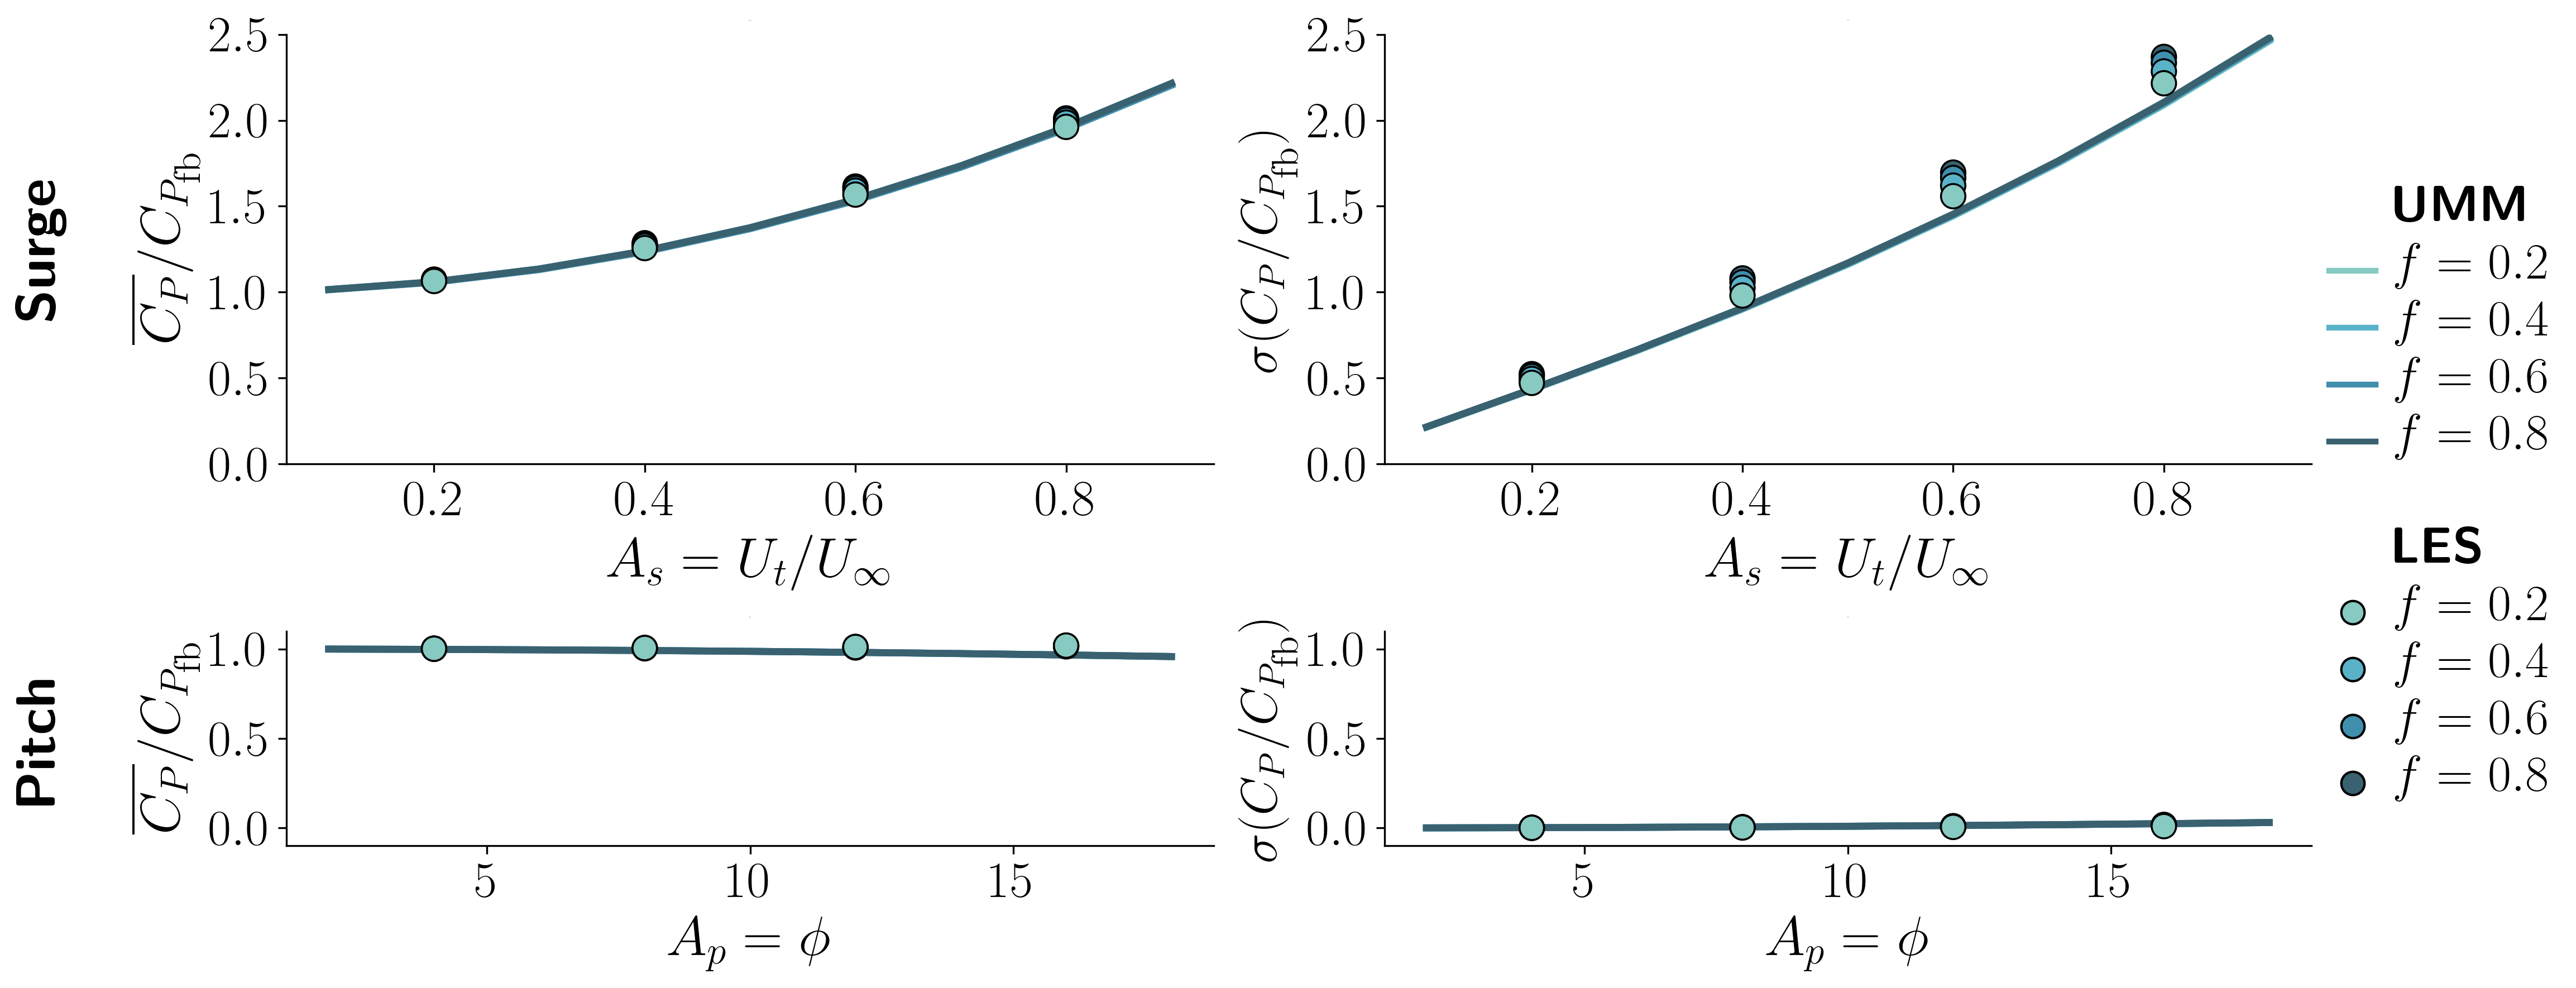

In [ ]:
g = sns.relplot(
    data=df_stat_les[(df_stat_les["Local Thrust Coefficient"] == 1.33)].sort_values(["Movement", "Frequency"], ascending=False),
    x="Amplitude",
    y="Cp_Turb_normalized",
    hue="Frequency",
    col = "stat",
    row="Movement",
    kind="scatter",
    palette=palette,
    height=4,
    aspect=1.2,
    facet_kws={"sharey": False, "sharex": False},
    zorder = 10,
    s = 110,
    edgecolor = "k",
)

for (movement, stat), ax in g.axes_dict.items():
    sns.lineplot(
        data=df_stat_umm[
            (df_stat_umm["Local Thrust Coefficient"] == 1.33) &
            (df_stat_umm["Movement"] == movement) &
            (df_stat_umm["stat"] == stat)
        ].sort_values(["Movement", "Frequency"], ascending=False),
        x="Amplitude",
        y="Cp_Turb_normalized",
        hue="Frequency",
        palette=palette,
        ax=ax,
        legend=False,   # avoid duplicate legend entries
        linewidth = 3
    )

for ax in g.axes[0, :]:   # row 0, all columns
    ax.set_ylim(0, 2.5)

for ax in g.axes[1, :]:   # row 1, all columns
    ax.set_ylim(-0.1, 1.1)

# Correct GridSpec object
rt = 2.5 + 1.2
gs = g.fig.axes[0].get_subplotspec().get_gridspec()
gs.set_height_ratios([3, 1.5])

for ax in g.axes.flatten():
    ax.yaxis.set_major_locator(MultipleLocator(0.5))

g.fig.set_size_inches(14, 6)
g.fig.set_dpi(300)

g._legend.remove()

# ====== Create custom legend entries ======

# LES subheaders: Amplitude and Frequency
space_header = Line2D([], [], linestyle="none", marker="", label=" ", color="none")

# UMM line legend header
umm_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{UMM}", color="none")

# Your line entries (UMM)
umm_handles = [
    Line2D([], [], color=palette[i], linewidth=2.5, label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]

# LES scatter legend header
les_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{LES}", color="none")

# Your scatter entries (LES)
les_handles = [
    Line2D([], [], color=palette[i], marker='o', linestyle="none",
           markersize=10, markeredgecolor="black", label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]
all_handles = [umm_header] + umm_handles + [space_header, les_header] + les_handles
g.fig.subplots_adjust(right=0.8)
leg = g.fig.legend(
    handles=all_handles,
    loc="center right",
    bbox_to_anchor=(1.1, 0.5),
    bbox_transform=g.fig.transFigure,
    frameon = False
)
# leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(label_size)
leg.get_title().set_fontweight("bold")
for text in leg.get_texts():
    text.set_fontsize(label_size )

# adjusting labels and such
for (i, ax) in enumerate(g.axes.flatten()):
    if i  < 2:
        ax.set_xlabel("$A_s = U_t / U_\infty$", fontsize = label_size + 2)
    else:
        ax.set_xlabel("$A_p = \phi$", fontsize = label_size + 2)
    
    if i == 0:
        ax.set_ylabel(
            "\\textbf{Surge}\n\n$\\overline{C_P} / C_{P_{\\textrm{\\fontsize{16}{16}\\selectfont fb}}}$",
            fontsize=label_size + 2
        )
    elif i == 2:
        ax.set_ylabel(
            "\\textbf{Pitch}\n\n$\\overline{C_P}/ C_{P_{\\textrm{\\fontsize{16}{16}\\selectfont fb}}} $",
            fontsize=label_size + 2
        )
    else:
        ax.set_ylabel(
            "$\\sigma (C_P/ C_{P_{\\textrm{\\fontsize{16}{16}\\selectfont fb}}})$",
            fontsize=label_size
        )

    # Tick labels
    ax.tick_params(axis='x', labelsize=label_size)
    ax.tick_params(axis='y', labelsize=label_size)

g.set_titles(col_template=" ", row_template= " ", size=0)

plt.tight_layout()
plt.show()

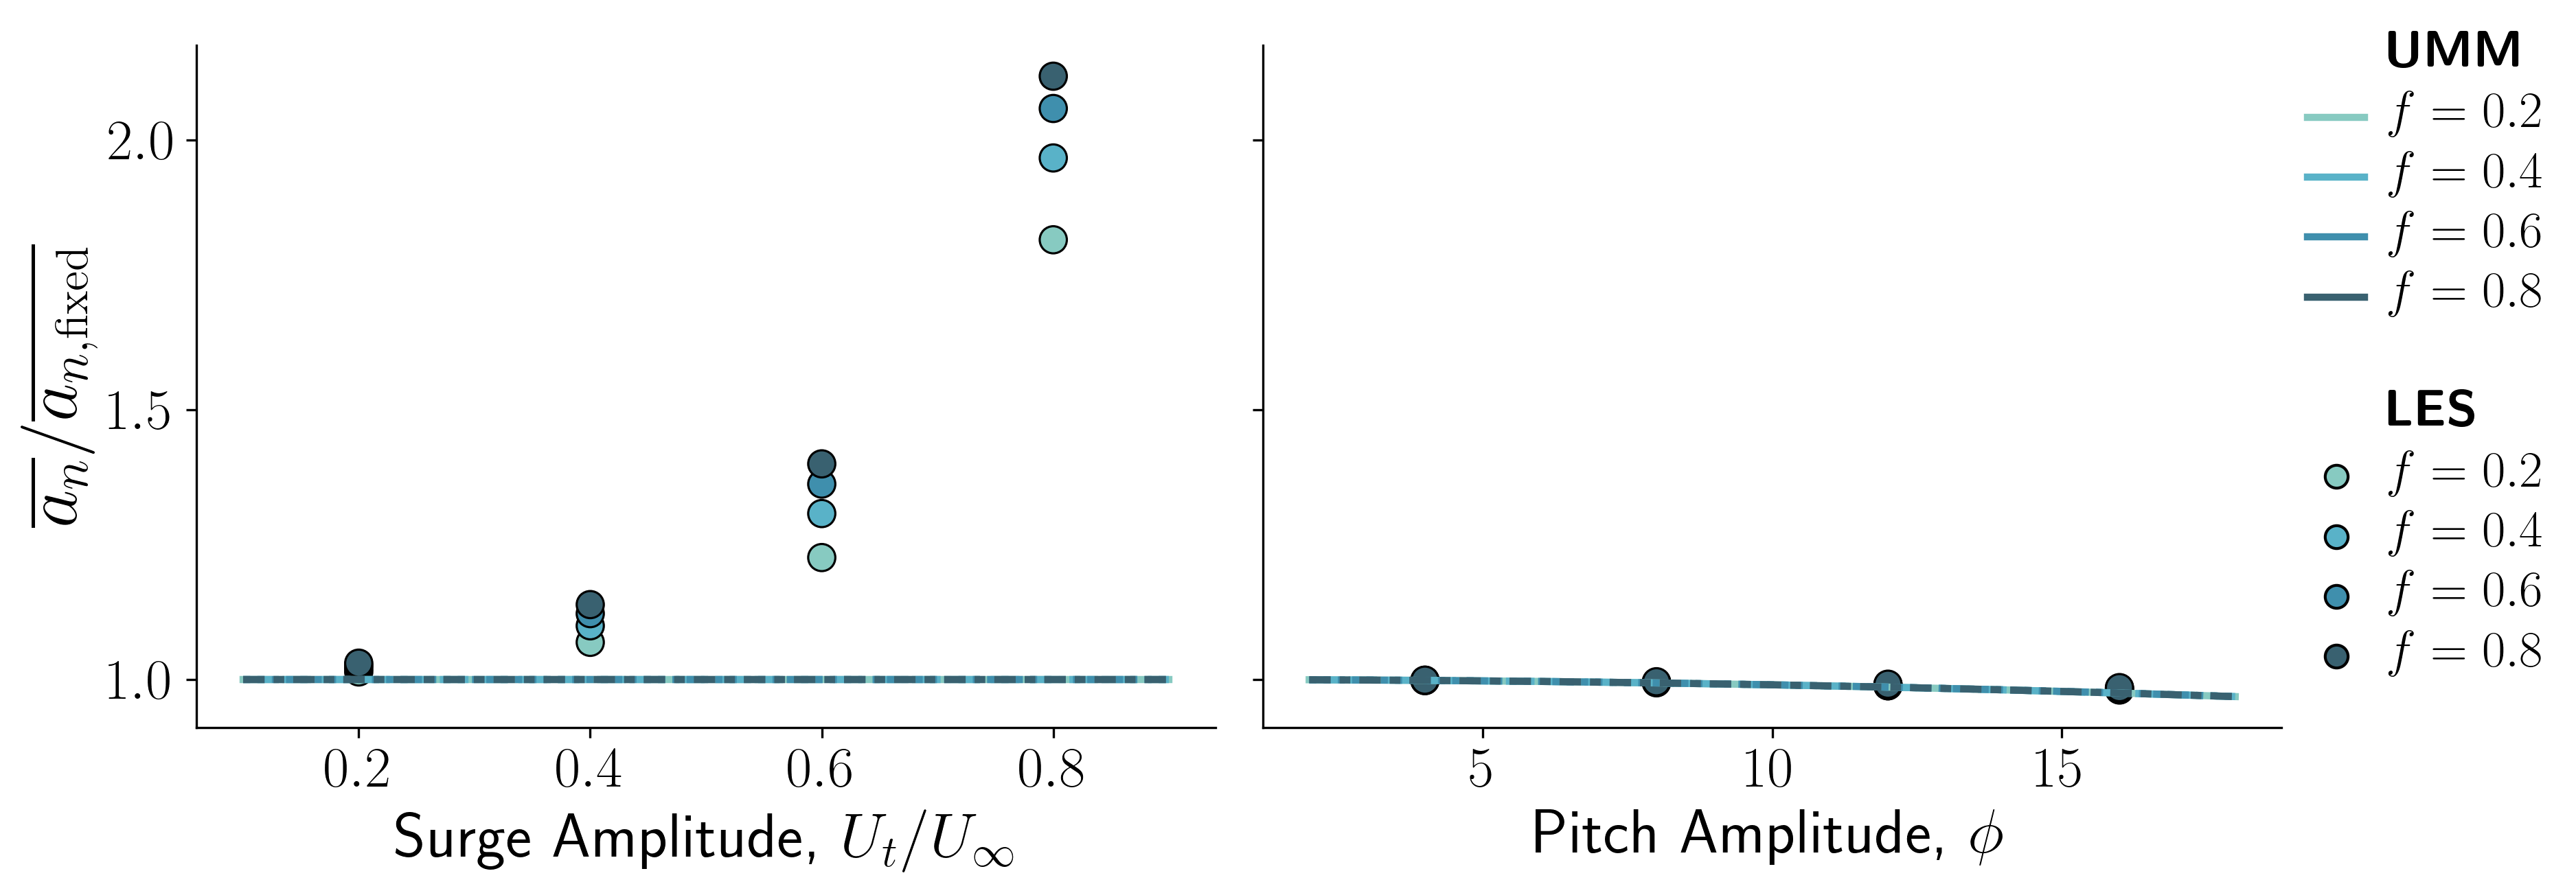

In [ ]:
# 2) Create the FacetGrid / relplot for the UMM lines (sharing y only)
g = sns.relplot(
    data=df_avg_umm[df_avg_umm["Local Thrust Coefficient"] == 1.33],
    x="Amplitude",
    y="an_Turb_normalized",
    hue="Frequency",
    style = "Frequency",
    col="Movement",
    kind="line",
    palette=palette,
    height=4,
    aspect=1.2,
    linewidth = 2.5,
    facet_kws={"sharey": True, "sharex": False},
    zorder = 10
)
g.fig.set_size_inches(14, 5)
g.fig.set_dpi(300)
g._legend.remove()
# 3) Overlay LES scatterpoints onto the corresponding axes
# IMPORTANT: do NOT pass sharex/sharey to sns.scatterplot
for (movement), ax in g.axes_dict.items():
    sns.scatterplot(
        data=df_avg_les[
            (df_avg_les["Local Thrust Coefficient"] == 1.33) &
            (df_avg_les["Movement"] == movement)
        ],
        x="Amplitude",
        y="an_Turb_normalized",
        hue="Frequency",
        palette=palette,
        ax=ax,
        legend=False,   # avoid duplicate legend entries
        s=90,
        edgecolor = "k"
    )

# 4) Final cosmetics (one legend, titles, y-limits etc.)
g.fig.subplots_adjust(top=0.8)
# g.fig.suptitle("Normalized Induction ($C_T' = 1.33$)", size = title_size + 2)

for (i, ax) in enumerate(g.axes.flatten()):
    if i == 0:
        ax.set_xlabel("Surge Amplitude, $U_t / U_\infty$", fontsize = label_size)
    else:
        ax.set_xlabel("Pitch Amplitude, $\phi$", fontsize = label_size)
    ax.set_ylabel(
        "$\\overline{a_n} / \\overline{a_{n,\\textrm{\\fontsize{16}{16}\\selectfont fixed}}}$",
        fontsize=label_size + 4
    )

    # Tick labels
    ax.tick_params(axis='x', labelsize=label_size - 2)
    ax.tick_params(axis='y', labelsize=label_size - 2)

# ====== Create custom legend entries ======

# LES subheaders: Amplitude and Frequency
space_header = Line2D([], [], linestyle="none", marker="", label=" ", color="none")

# UMM line legend header
umm_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{UMM}", color="none")

# Your line entries (UMM)
umm_handles = [
    Line2D([], [], color=palette[i], linewidth=2.5, label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]

# LES scatter legend header
les_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{LES}", color="none")

# Your scatter entries (LES)
les_handles = [
    Line2D([], [], color=palette[i], marker='o', linestyle="none",
           markersize=8, markeredgecolor="black", label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]
all_handles = [umm_header] + umm_handles + [space_header, les_header] + les_handles
g.fig.subplots_adjust(right=0.8)
leg = g.fig.legend(
    handles=all_handles,
    loc="center right",
    bbox_to_anchor=(0.9, 0.5),
    bbox_transform=g.fig.transFigure,
    frameon = False
)
# leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(label_size)
leg.get_title().set_fontweight("bold")
for text in leg.get_texts():
    text.set_fontsize(label_size - 4)

g.set_titles(col_template=" ", size=0)

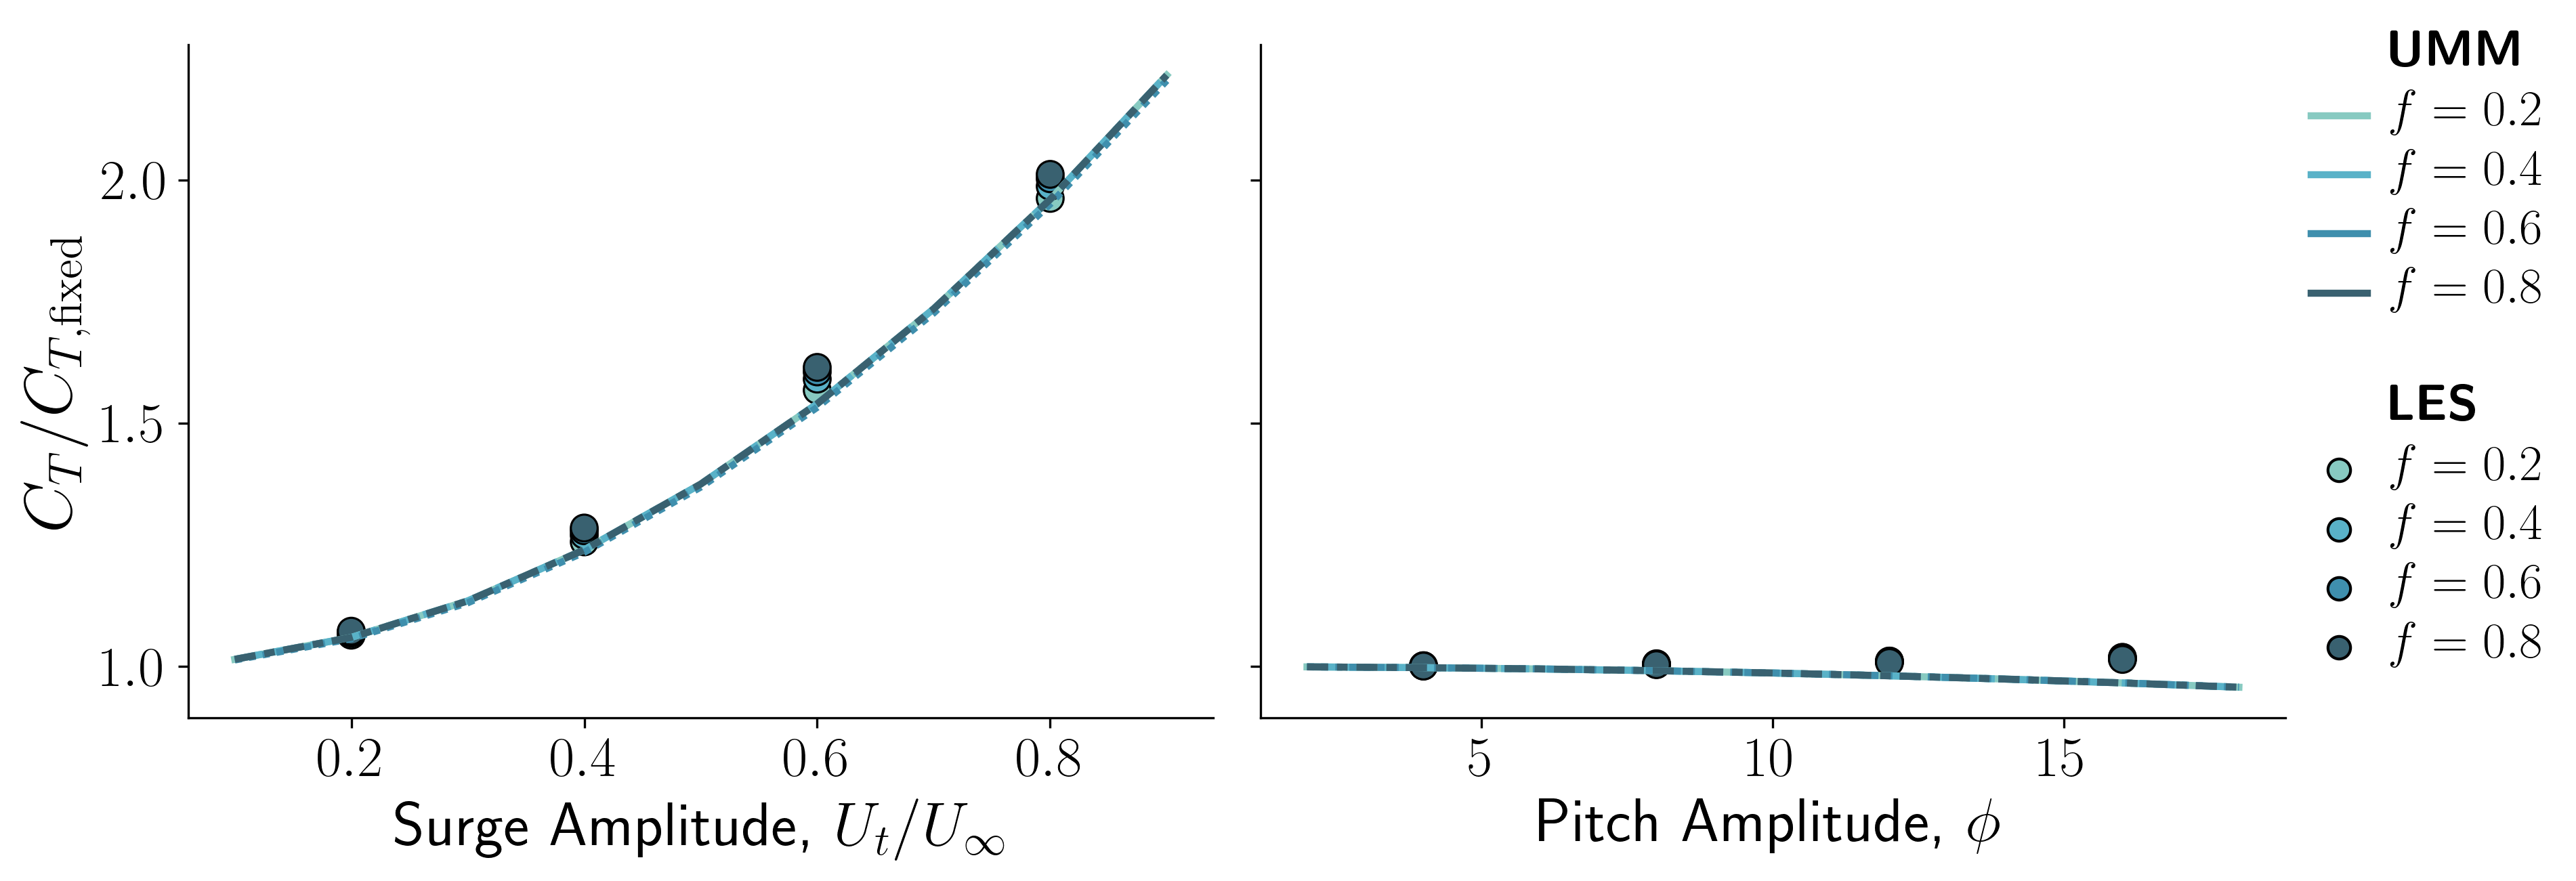

In [ ]:
label_size = 22
title_size = 24

freqs = sorted(df_avg_umm["Frequency"].unique())
freqs = np.round(freqs, decimals=2)
palette = sns.color_palette("GnBu_d", n_colors=len(freqs))

# 2) Create the FacetGrid / relplot for the UMM lines (sharing y only)
g = sns.relplot(
    data=df_avg_umm[df_avg_umm["Local Thrust Coefficient"] == 1.33],
    x="Amplitude",
    y="Cp_Turb_normalized",
    hue="Frequency",
    style = "Frequency",
    col="Movement",
    kind="line",
    palette=palette,
    height=4,
    aspect=1.2,
    linewidth = 2.5,
    facet_kws={"sharey": True, "sharex": False},
    zorder = 10
)
g.fig.set_size_inches(14, 5)
g.fig.set_dpi(300)
g._legend.remove()
# 3) Overlay LES scatterpoints onto the corresponding axes
# IMPORTANT: do NOT pass sharex/sharey to sns.scatterplot
for (movement), ax in g.axes_dict.items():
    sns.scatterplot(
        data=df_avg_les[
            (df_avg_les["Local Thrust Coefficient"] == 1.33) &
            (df_avg_les["Movement"] == movement)
        ],
        x="Amplitude",
        y="Cp_Turb_normalized",
        hue="Frequency",
        palette=palette,
        ax=ax,
        legend=False,   # avoid duplicate legend entries
        s=90,
        edgecolor = "k",
        zorder = 0
    )

# 4) Final cosmetics (one legend, titles, y-limits etc.)
g.fig.subplots_adjust(top=0.8)
# g.fig.suptitle("Normalized Induction ($C_T' = 1.33$)", size = title_size + 2)

for (i, ax) in enumerate(g.axes.flatten()):
    if i == 0:
        ax.set_xlabel("Surge Amplitude, $U_t / U_\infty$", fontsize = label_size)
    else:
        ax.set_xlabel("Pitch Amplitude, $\phi$", fontsize = label_size)
    ax.set_ylabel(
        "$C_T / C_{T,\\textrm{\\fontsize{16}{16}\\selectfont fixed}}$",
        fontsize=label_size + 2
    )

    # Tick labels
    ax.tick_params(axis='x', labelsize=label_size - 2)
    ax.tick_params(axis='y', labelsize=label_size - 2)

# ====== Create custom legend entries ======

# LES subheaders: Amplitude and Frequency
space_header = Line2D([], [], linestyle="none", marker="", label=" ", color="none")

# UMM line legend header
umm_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{UMM}", color="none")

# Your line entries (UMM)
umm_handles = [
    Line2D([], [], color=palette[i], linewidth=2.5, label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]

# LES scatter legend header
les_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{LES}", color="none")

# Your scatter entries (LES)
les_handles = [
    Line2D([], [], color=palette[i], marker='o', linestyle="none",
           markersize=8, markeredgecolor="black", label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]
all_handles = [umm_header] + umm_handles + [space_header, les_header] + les_handles
g.fig.subplots_adjust(right=0.8)
leg = g.fig.legend(
    handles=all_handles,
    loc="center right",
    bbox_to_anchor=(0.9, 0.5),
    bbox_transform=g.fig.transFigure,
    frameon = False
)
# leg.get_title().set_fontweight('bold')
leg.get_title().set_fontsize(label_size)
leg.get_title().set_fontweight("bold")
for text in leg.get_texts():
    text.set_fontsize(label_size - 4)

g.set_titles(col_template=" ", size=0)

In [ ]:
pitch_les = df_avg_les[df_avg_les["Movement"] == "Pitch"]

<Axes: xlabel='Distance', ylabel='Cp_Turb'>

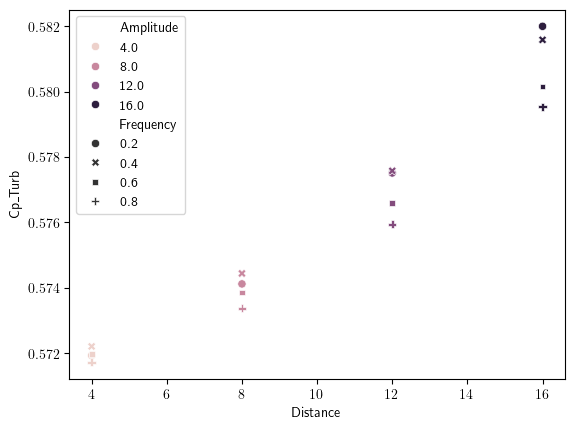

In [ ]:
pitch_les = df_avg_les[(df_avg_les["Movement"] == "Pitch") & (df_avg_les["Local Thrust Coefficient"] == 1.33)]
sns.scatterplot(x = pitch_les["Distance"], y = pitch_les["Cp_Turb"], hue = pitch_les["Amplitude"], style = pitch_les["Frequency"])

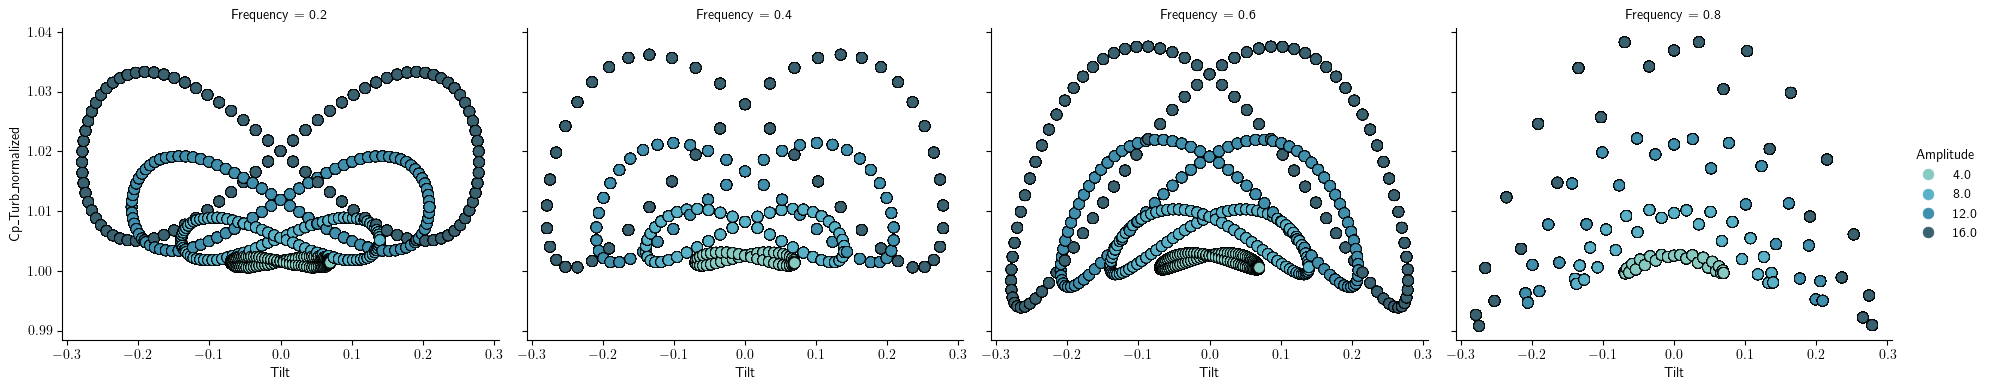

In [ ]:
pitch_les = df_les[(df_les["Movement"] == "Pitch") & (df_les["Local Thrust Coefficient"] == 1.33)]
g = sns.relplot(
    data=pitch_les.sort_values(by = ["Tilt"]),
    x="Tilt",
    y="Cp_Turb_normalized",
    hue="Amplitude",
    palette=palette,
    edgecolors = "k",
    s = 60,
    linewidth=0.5,
    kind="scatter",
    col="Frequency",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True},
)

In [ ]:
df_umm_box = df_umm[(df_umm["Local Thrust Coefficient"] == 1.33)]
df_umm_box["Model"] = "UMM"

df_les_box = df_les[(df_les["Local Thrust Coefficient"] == 1.33)]
df_les_box["Model"] = "LES"

/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3402659726.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_umm_box["Model"] = "UMM"
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/3402659726.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_les_box["Model"] = "LES"


In [ ]:
df_box = pd.concat([df_umm_box, df_les_box], ignore_index=True)
df_box["Model_Frequency"] = df_box['Model'].astype(str) + ': f = ' + df_box['Frequency'].astype(str)
df_box["Amplitude"] = np.round(df_box["Amplitude"], decimals=1)
df_box = df_box[df_box["Amplitude"] % 0.2 == 0]
df_box

,Local Thrust Coefficient,Amplitude,Distance,Tilt,Frequency,UTurb,an_Turb,an_Turb_normalized,Ct_Turb,Ct_Turb_normalized,...,Model,Unnamed: 0,DeltaX,Time,TIDX,Power,UInf_Ground,Phase,Phase_Shifted,Model_Frequency
417,1.33,0.2,0.159155,0.0,0.2,0.200000,0.249143,1.000000,0.479895,0.640000,...,UMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UMM: f = 0.2
418,1.33,0.2,0.159155,0.0,0.2,0.199605,0.249143,1.000000,0.480369,0.640632,...,UMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UMM: f = 0.2
419,1.33,0.2,0.159155,0.0,0.2,0.198423,0.249143,1.000000,0.481789,0.642526,...,UMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UMM: f = 0.2
420,1.33,0.2,0.159155,0.0,0.2,0.196457,0.249143,1.000000,0.484155,0.645681,...,UMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UMM: f = 0.2
421,1.33,0.2,0.159155,0.0,0.2,0.193717,0.249143,1.000000,0.487463,0.650093,...,UMM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UMM: f = 0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71501,1.33,0.8,NaN,0.0,0.8,0.583175,0.714260,2.908498,0.018867,0.024924,...,LES,75995.0,-1.089491e-01,299.80,5996.0,8.824467e-04,1.0,8.800000e-01,0.38,LES: f = 0.8
71502,1.33,0.8,NaN,0.0,0.8,0.701045,0.971118,3.954437,0.000099,0.000131,...,LES,75996.0,-7.667348e-02,299.85,5997.0,3.362163e-07,1.0,9.200000e-01,0.42,LES: f = 0.8
71503,1.33,0.8,NaN,0.0,0.8,0.774867,1.280358,5.213680,-0.005299,-0.007000,...,LES,75997.0,-3.958022e-02,299.90,5998.0,-1.313326e-04,1.0,9.600000e-01,0.46,LES: f = 0.8
71504,1.33,0.8,NaN,0.0,0.8,0.800000,1.453817,5.920013,-0.010957,-0.014474,...,LES,75998.0,2.714947e-11,299.95,5999.0,-3.905214e-04,1.0,2.714947e-11,0.50,LES: f = 0.8


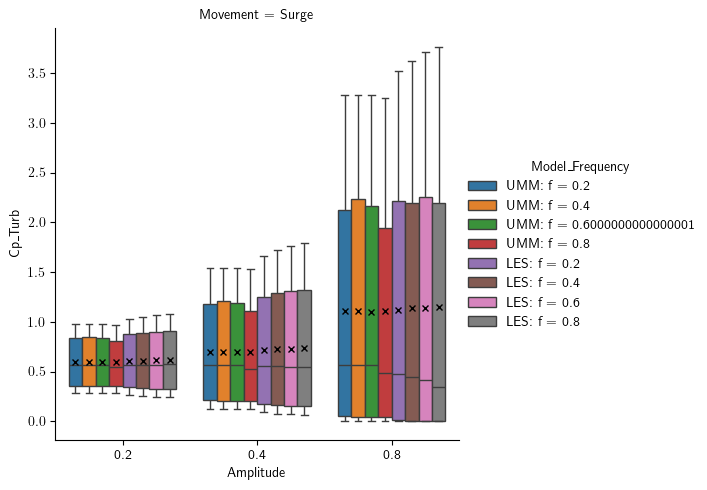

In [ ]:
g = sns.catplot(
    data=df_box,
    x="Amplitude",
    y="Cp_Turb",
    hue="Model_Frequency",
    col="Movement",
    kind="box",
    palette="tab10",
    sharey = True,
    sharex=False,
    showmeans=True,
    meanprops={
        "marker": "x",        # Diamond shape
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4
    }
)

# g.figure.suptitle('Pitching Turbine: $a_n$ vs Amplitude', y = 1.05)

# g.set_titles(col_template="$C_T'$ = {col_name}")
# g.set_axis_labels("Amplitude", "$a_n$")

In [ ]:
df_phase_avg_les_surge = df_phase_avg_les[df_phase_avg_les["Movement"] == "Surge"]
df_total_avg_umm_surge_ct_133 = df_avg_umm[(df_avg_umm["Local Thrust Coefficient"] == 1.33) & (df_avg_umm["Movement"] == "Surge")]
df_total_avg_umm_surge_ct_200 = df_avg_umm[(df_avg_umm["Local Thrust Coefficient"] == 2.00) & (df_avg_umm["Movement"] == "Surge")]

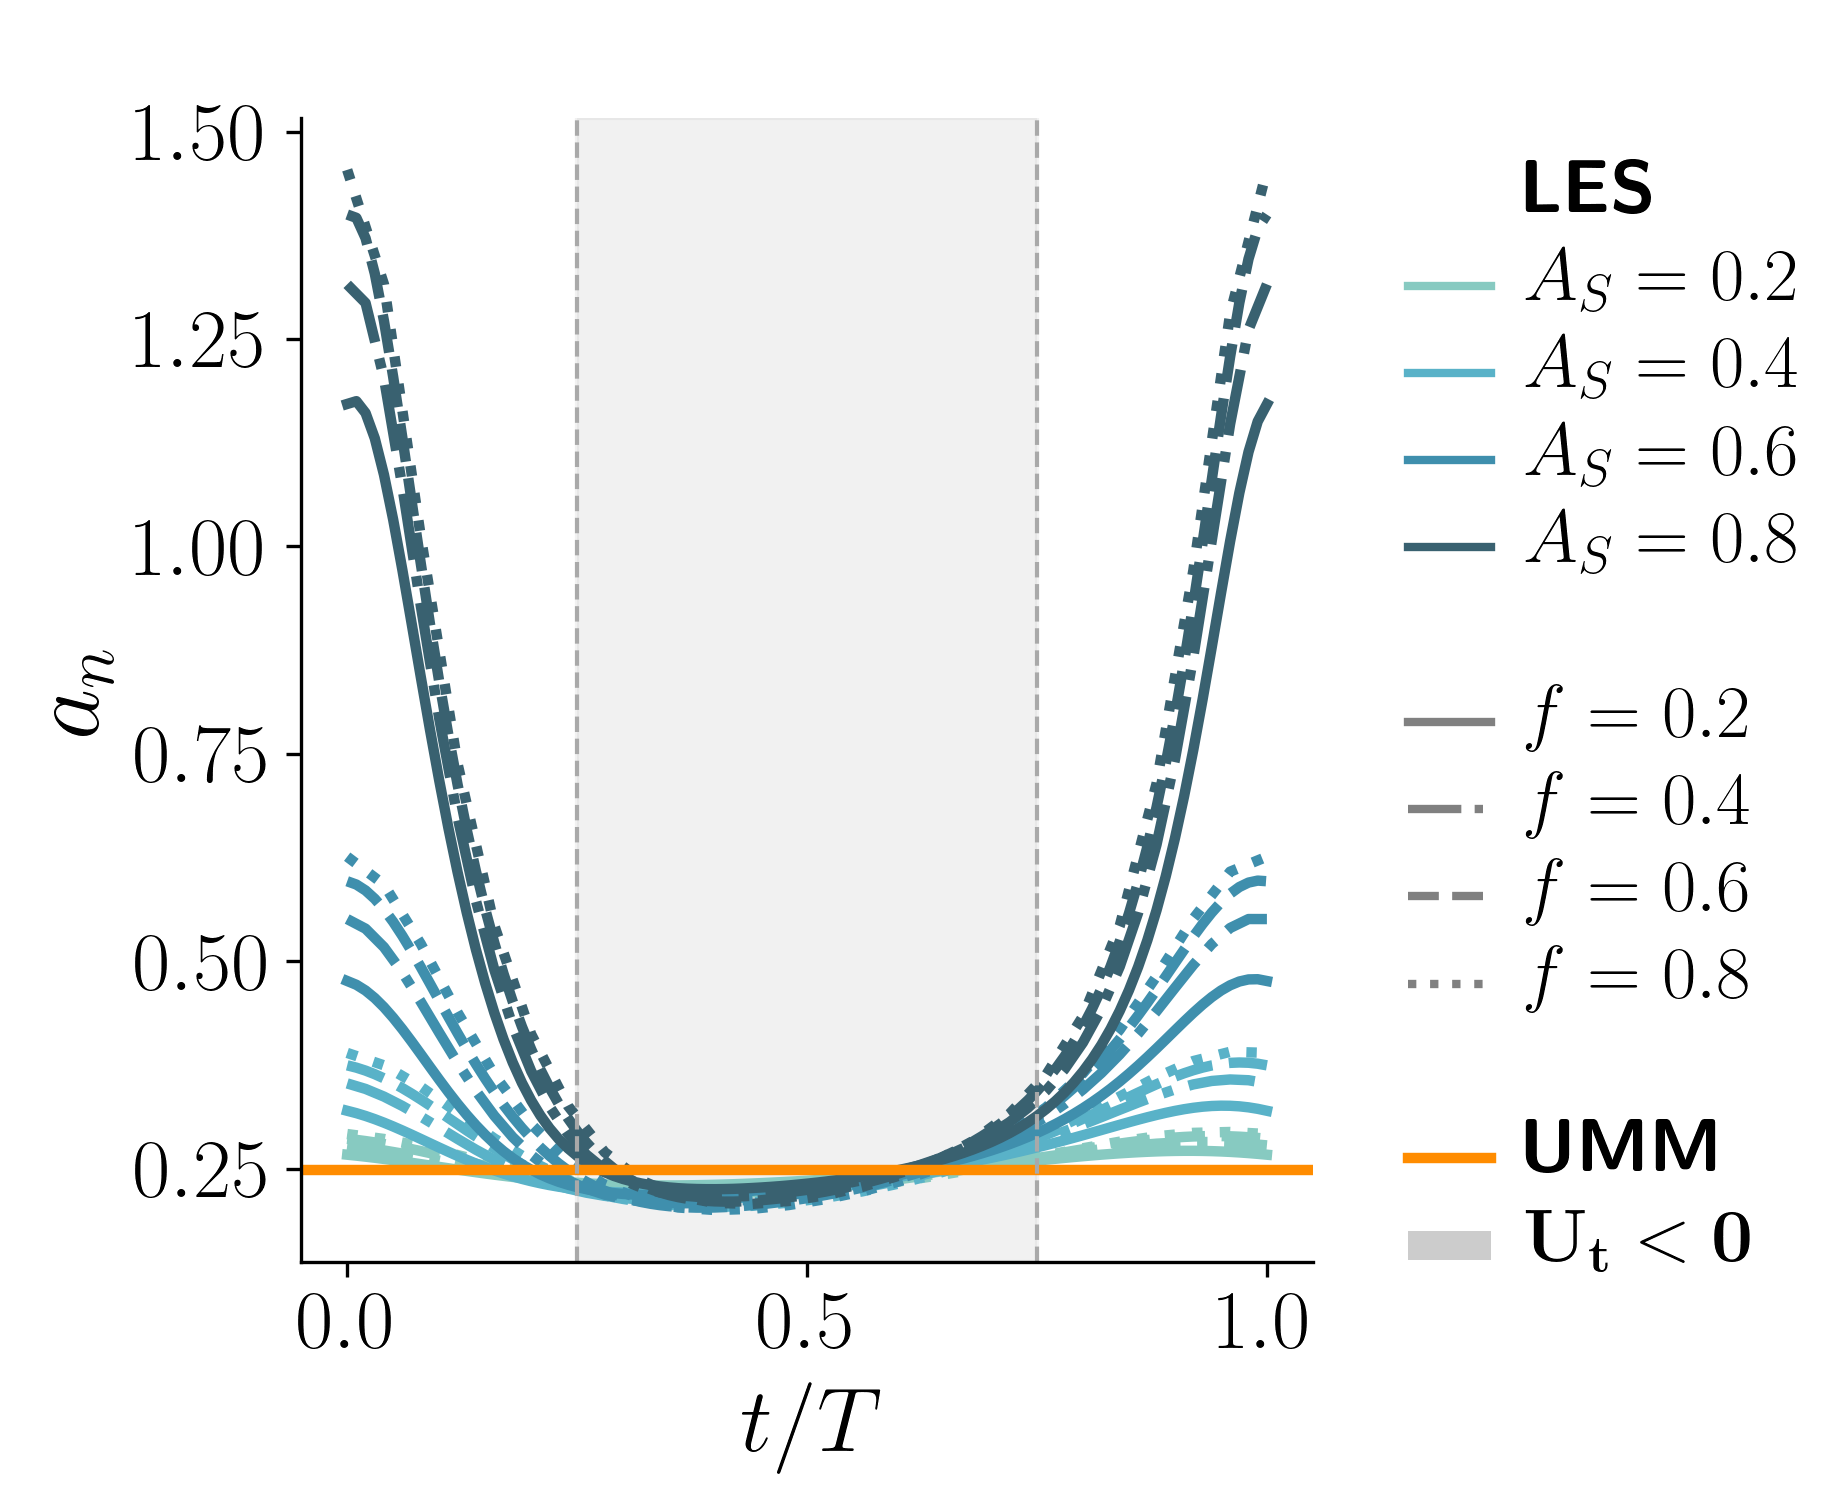

In [ ]:
# Create the relplot with columns based on "Local Thrust Velocity"
g = sns.relplot(
    data=df_phase_avg_les_surge[df_phase_avg_les_surge["Local Thrust Coefficient"] == 1.33],
    x="Phase_Rounded",
    y="an_Turb",
    hue="Amplitude",
    style="Frequency",
    palette=palette,
    linewidth=2.5,
    kind="line",
    col="Local Thrust Coefficient",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True},
)


g.fig.set_size_inches(5, 5)
g.fig.set_dpi(300)
g._legend.remove()

# Apply custom line styles for frequencies
freq_styles = ['-', '-.', '--', ':']
freqs = sorted(df_phase_avg_les_surge["Frequency"].unique())
for ax in g.axes.flatten():
    lines = ax.get_lines()
    for i, line in enumerate(lines):
        freq_idx = i % len(freqs)  # match line index to frequency
        line.set_linestyle(freq_styles[freq_idx])

# Add the UMM horizontal line to each axis
for (i, ax) in enumerate(g.axes.flatten()):
    # ax.set_box_aspect(0.5)  
    if i == 0:
        vals = df_total_avg_umm_surge_ct_133
    else:
        vals = df_total_avg_umm_surge_ct_200
    umm_mean = np.mean(vals["an_Turb"])
    ax.axhline(y=umm_mean, c="darkorange", linewidth=2.5)
    ax.axvline(0.25, color='darkgrey', linestyle='--', linewidth=1)
    ax.axvline(0.75, color='darkgrey', linestyle='--', linewidth=1)
    # shaded vertical region between x1 and x2
    shade_label = '$U_{\infty, t} > U_{\infty, g}$ ($u_{t, g} < 0$)'
    ax.axvspan(0.25, 0.75, color='lightgrey', alpha=0.3, label=shade_label)

# ====== Custom legend ======
# LES main header (bold)
les_header = Line2D([], [], linestyle="none", marker="", label=r"\textbf{LES}", color="none")

# LES subheaders: Amplitude and Frequency
space_header = Line2D([], [], linestyle="none", marker="", label=" ", color="none")

# LES handles (colors for amplitudes)
amps = sorted(df_phase_avg_les_surge["Amplitude"].unique())
amp_handles = [Line2D([], [], color=palette[i], lw=2, label=f"$A_S = {amps[i]}$") for i in range(len(amps))]

# LES handles (line styles for frequencies)
freqs = sorted(df_phase_avg_les_surge["Frequency"].unique())
freq_handles = [Line2D([], [], color='grey', linestyle=freq_styles[i % len(freq_styles)], lw=2, label=f"$f = {freqs[i]}$") for i in range(len(freqs))]

# UMM line handle
umm_header = Line2D([], [], color="darkorange", linewidth=2.5, label=r"\textbf{UMM}")

# Shaded region handle
shade_handle = Patch(
    facecolor='grey',
    edgecolor='none',
    alpha=0.4,
    label='$\\mathbf{U_{t} < 0}$'
)

# Combine all handles
all_handles = [les_header] + amp_handles + [space_header] + freq_handles + [space_header, umm_header, shade_handle]

# Place the legend outside the plot (right)
g.fig.subplots_adjust(right=0.8)
leg = g.fig.legend(
    handles=all_handles,
    # title="Frequency",
    loc="center right",
    bbox_to_anchor=(1.15, 0.5),
    bbox_transform=g.fig.transFigure,
    frameon = False
)

for text in leg.get_texts():
    text.set_fontsize(label_size - 4)

# Set labels and title for the whole figure
g.set_titles(" ", size=label_size)
for ax in g.axes.flatten():
    ax.set_xlabel("$t/T$", fontsize=label_size)
    ax.set_ylabel("$a_n$", fontsize=label_size + 2)
    ax.tick_params(axis="both", labelsize=label_size - 2)
    ax.tick_params(axis="y", labelsize=label_size - 2)

# g.fig.suptitle("Surging Phase-Averaged Induction", fontsize=title_size)
# g.fig.tight_layout()
g.fig.subplots_adjust(top=0.9)  # leave space for suptitle
g.fig.set_dpi(300)

In [ ]:
palette = sns.color_palette("viridis_r", n_colors=len(freqs))
palette = [palette[0], palette[2], palette[3], palette[1]]
palette

[(0.477504, 0.821444, 0.318195),
 (0.163625, 0.471133, 0.558148),
 (0.253935, 0.265254, 0.529983),
 (0.134692, 0.658636, 0.517649)]

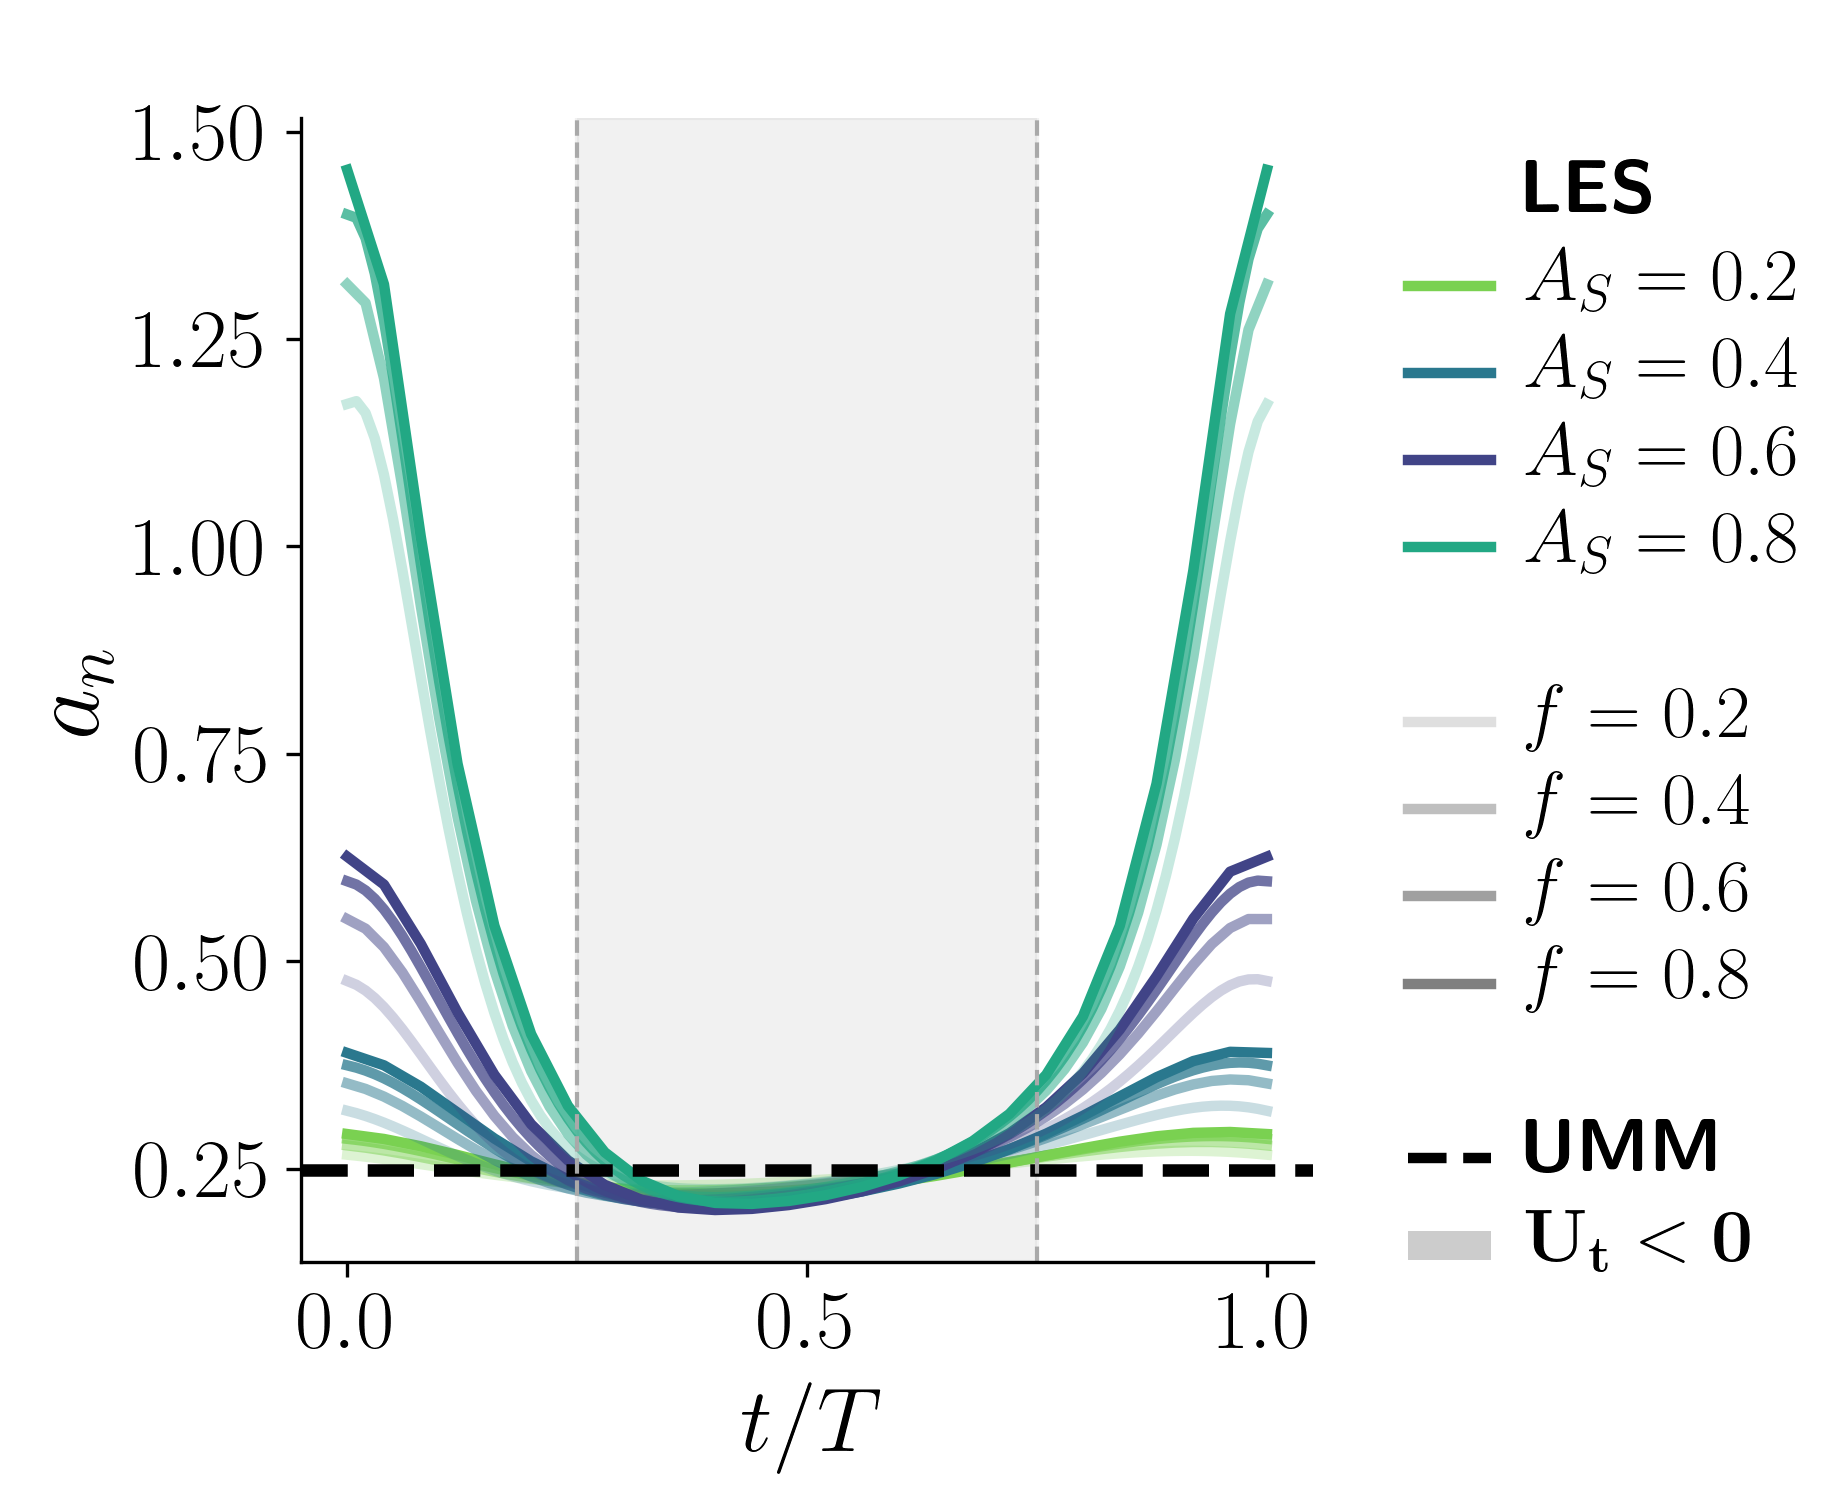

In [ ]:
# ===================== CREATE RELPLOT =====================
import itertools
g = sns.relplot(
    data=df_phase_avg_les_surge[df_phase_avg_les_surge["Local Thrust Coefficient"] == 1.33],
    x="Phase_Rounded",
    y="an_Turb",
    hue="Amplitude",
    style="Frequency",
    palette=palette,
    linewidth=2.5,
    kind="line",
    col="Local Thrust Coefficient",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True}
)

g.fig.set_size_inches(5, 5)
g.fig.set_dpi(300)

# Remove Seaborn's auto-legend
g._legend.remove()


# ===================== APPLY ALPHA + SOLID LINES =====================
# Frequency order and alpha values
freqs = sorted(df_phase_avg_les_surge["Frequency"].unique())
alpha_vals = ([1.0, 0.75, 0.5, 0.25])
alpha_vals.reverse()

# Number of amplitudes
amps_sorted = sorted(df_phase_avg_les_surge["Amplitude"].unique())
n_amp = len(amps_sorted)

# Apply alpha and force solid linestyle
for ax in g.axes.flatten():
    lines = ax.get_lines()

    # Repeat alpha for each amplitude per frequency
    alphas = alpha_vals * 4

    for line, alpha in zip(lines, alphas):
        line.set_alpha(alpha)
        line.set_linestyle("-")
# ====================== ADD UMM + SHADING ======================
for i, ax in enumerate(g.axes.flatten()):
    vals = df_total_avg_umm_surge_ct_133 if i == 0 else df_total_avg_umm_surge_ct_200
    umm_mean = np.mean(vals["an_Turb"])

    ax.axhline(y=umm_mean, c="k", linewidth=3, linestyle = "--")
    ax.axvline(0.25, color='darkgrey', linestyle='--', linewidth=1)
    ax.axvline(0.75, color='darkgrey', linestyle='--', linewidth=1)

    ax.axvspan(0.25, 0.75, color='lightgrey', alpha=0.3,
               label='$U_{\\infty,t} > U_{\\infty,g}$ ($u_{t,g} < 0$)')


# ======================= CUSTOM LEGEND =========================
les_header = Line2D([], [], linestyle="none", marker="", 
                    label=r"\textbf{LES}", color="none")

space_header = Line2D([], [], linestyle="none", marker="", label=" ", color="none")

# Amplitude handles
amp_handles = [
    Line2D([], [], color=palette[i], lw=2.5, label=f"$A_S = {amps_sorted[i]}$")
    for i in range(len(amps_sorted))
]

# Frequency handles (solid lines, alpha matches plot)
freq_handles = [
    Line2D([], [], color="grey", lw=2.5, linestyle="-",
           alpha=alpha_vals[i], label=f"$f = {freqs[i]}$")
    for i in range(len(freqs))
]

# UMM handle
umm_header = Line2D([], [], color="k", linewidth=2.5, linestyle="--",
                    label=r"\textbf{UMM}")

# Shaded region handle
shade_handle = Patch(facecolor='grey', edgecolor='none', alpha=0.4,
                     label=r"$\mathbf{U_{t} < 0}$")

# Combine legend handles
all_handles = ([les_header] + amp_handles +
               [space_header] + freq_handles +
               [space_header, umm_header, shade_handle])

# Place legend outside plot
g.fig.subplots_adjust(right=0.8)
leg = g.fig.legend(handles=all_handles, loc="center right",
                   bbox_to_anchor=(1.15, 0.5),
                   bbox_transform=g.fig.transFigure,
                   frameon=False)

# Style legend
for text in leg.get_texts():
    text.set_fontsize(label_size - 4)


# ======================= LABELS & TITLES =======================
g.set_titles(" ", size=label_size)

for ax in g.axes.flatten():
    ax.set_xlabel("$t/T$", fontsize=label_size)
    ax.set_ylabel("$a_n$", fontsize=label_size + 2)
    ax.tick_params(axis="both", labelsize=label_size - 2)

g.fig.subplots_adjust(top=0.9)
g.fig.set_dpi(300)

In [ ]:
df_phase_avg_les_surge

,Frequency,Amplitude,Movement,Local Thrust Coefficient,Phase_Rounded,an_Turb,Phase_Shifted,UTurb,UDisk_Turb,UDisk_Ground,UInf_Turb
0,0.2,0.2,Surge,1.33,0.00,0.267121,0.50,0.200000,0.586303,0.786303,0.800000
1,0.2,0.2,Surge,1.33,0.01,0.265986,0.51,0.199605,0.587501,0.787106,0.800395
2,0.2,0.2,Surge,1.33,0.02,0.264750,0.52,0.198423,0.589360,0.787783,0.801577
3,0.2,0.2,Surge,1.33,0.03,0.263420,0.53,0.196457,0.591874,0.788331,0.803543
4,0.2,0.2,Surge,1.33,0.04,0.262007,0.54,0.193717,0.595032,0.788748,0.806283
...,...,...,...,...,...,...,...,...,...,...,...
2251,0.8,0.8,Surge,2.00,0.84,0.735348,0.34,0.428661,0.151206,0.579867,0.571339
2252,0.8,0.8,Surge,2.00,0.88,0.973823,0.38,0.583175,0.010911,0.594086,0.416825
2253,0.8,0.8,Surge,2.00,0.92,1.337292,0.42,0.701045,-0.100835,0.600210,0.298955
2254,0.8,0.8,Surge,2.00,0.96,1.786005,0.46,0.774867,-0.176956,0.597910,0.225133


In [ ]:
les_udisk_stationary_ct_133 = (1 - les_an_stationary_ct_133[0])
umm_udisk_stationary_ct_133 = (1 - model(1.33, yaw = 0.0, tilt = 0.0).an)

In [ ]:
sub_df_phase_avg_les_surge = df_phase_avg_les_surge[((df_phase_avg_les_surge["Amplitude"] == 0.6) | (df_phase_avg_les_surge["Amplitude"] == 0.8))]
sub_df_phase_avg_les_surge = sub_df_phase_avg_les_surge[(sub_df_phase_avg_les_surge["Local Thrust Coefficient"] == 1.33)]
sub_df_phase_avg_les_surge["UDisk_Ground_Normalized"] = sub_df_phase_avg_les_surge["UDisk_Ground"] / les_udisk_stationary_ct_133
sub_df_phase_avg_les_surge["UDisk_Turb_Normalized"] = sub_df_phase_avg_les_surge["UDisk_Turb"] / les_udisk_stationary_ct_133
sub_df_phase_avg_les_surge.sort_values(by = ["Phase_Rounded"])

,Frequency,Amplitude,Movement,Local Thrust Coefficient,Phase_Rounded,an_Turb,Phase_Shifted,UTurb,UDisk_Turb,UDisk_Ground,UInf_Turb,UDisk_Ground_Normalized,UDisk_Turb_Normalized
404,0.2,0.6,Surge,1.33,0.0,0.476431,0.5,0.6,0.209428,0.809428,0.4,1.072909,0.277600
1020,0.4,0.6,Surge,1.33,0.0,0.551070,0.5,0.6,0.179572,0.779572,0.4,1.033335,0.238025
1838,0.6,0.8,Surge,1.33,0.0,1.400020,0.5,0.8,-0.080004,0.719996,0.2,0.954366,-0.106047
606,0.2,0.8,Surge,1.33,0.0,1.171746,0.5,0.8,-0.034349,0.765651,0.2,1.014882,-0.045530
1636,0.6,0.6,Surge,1.33,0.0,0.596628,0.5,0.6,0.161349,0.761349,0.4,1.009180,0.213871
...,...,...,...,...,...,...,...,...,...,...,...,...,...
706,0.2,0.8,Surge,1.33,1.0,1.171475,0.5,0.8,-0.034295,0.765705,0.2,1.014954,-0.045459
504,0.2,0.6,Surge,1.33,1.0,0.476433,0.5,0.6,0.209427,0.809427,0.4,1.072908,0.277599
1938,0.6,0.8,Surge,1.33,1.0,1.399989,0.5,0.8,-0.079998,0.720002,0.2,0.954374,-0.106038
2177,0.8,0.6,Surge,1.33,1.0,0.626231,0.5,0.6,0.149508,0.749508,0.4,0.993484,0.198175


In [ ]:
sub_df_umm_surge = df_umm[(df_umm["Local Thrust Coefficient"] == 1.33) & (df_umm["Movement"] == "Surge")]
sub_df_umm_surge["UDisk_Ground_Normalized"] = sub_df_umm_surge["UDisk_Ground"] / umm_udisk_stationary_ct_133
sub_df_umm_surge["UDisk_Turb_Normalized"] = sub_df_umm_surge["UDisk_Turb"] / umm_udisk_stationary_ct_133
sub_df_umm_surge.sort_values(by = ["Phase_Rounded"])

/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/2566632304.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_umm_surge["UDisk_Ground_Normalized"] = sub_df_umm_surge["UDisk_Ground"] / umm_udisk_stationary_ct_133
/var/folders/dt/wzb0_01j5yz8q2y9bz5sfjm00000gn/T/ipykernel_4813/2566632304.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_df_umm_surge["UDisk_Turb_Normalized"] = sub_df_umm_surge["UDisk_Turb"] / umm_udisk_stationary_ct_133


,Local Thrust Coefficient,Amplitude,Distance,Tilt,Frequency,UTurb,an_Turb,an_Turb_normalized,Ct_Turb,Ct_Turb_normalized,Cp_Turb,Cp_Turb_normalized,Phase_Rounded,Movement,UTurb,UInf_Turb,UDisk_Turb,UDisk_Ground,UDisk_Ground_Normalized,UDisk_Turb_Normalized
0,1.33,0.1,0.079577,0.0,0.2,0.1,0.249143,1.0,0.607368,0.81,0.410442,0.729,0.0,Surge,NaN,0.9,0.675772,0.775772,1.033181,0.9
3336,1.33,0.9,0.716197,0.0,0.2,0.9,0.249143,1.0,0.007498,0.01,0.000563,0.001,0.0,Surge,NaN,0.1,0.075086,0.975086,1.298630,0.1
3286,1.33,0.8,0.159155,0.0,0.8,0.8,0.249143,1.0,0.029993,0.04,0.004504,0.008,0.0,Surge,NaN,0.2,0.150171,0.950171,1.265449,0.2
3219,1.33,0.8,0.212207,0.0,0.6,0.8,0.249143,1.0,0.029993,0.04,0.004504,0.008,0.0,Surge,NaN,0.2,0.150171,0.950171,1.265449,0.2
3119,1.33,0.8,0.318310,0.0,0.4,0.8,0.249143,1.0,0.029993,0.04,0.004504,0.008,0.0,Surge,NaN,0.2,0.150171,0.950171,1.265449,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
934,1.33,0.3,0.238732,0.0,0.2,0.3,0.249143,1.0,0.367420,0.49,0.193116,0.343,1.0,Surge,NaN,0.7,0.525600,0.825600,1.099543,0.7
1226,1.33,0.3,0.059683,0.0,0.8,0.3,0.249143,1.0,0.367420,0.49,0.193116,0.343,1.0,Surge,NaN,0.7,0.525600,0.825600,1.099543,0.7
1501,1.33,0.4,0.159155,0.0,0.4,0.4,0.249143,1.0,0.269941,0.36,0.121612,0.216,1.0,Surge,NaN,0.6,0.450514,0.850514,1.132724,0.6
667,1.33,0.2,0.079577,0.0,0.4,0.2,0.249143,1.0,0.479895,0.64,0.288266,0.512,1.0,Surge,NaN,0.8,0.600686,0.800686,1.066362,0.8


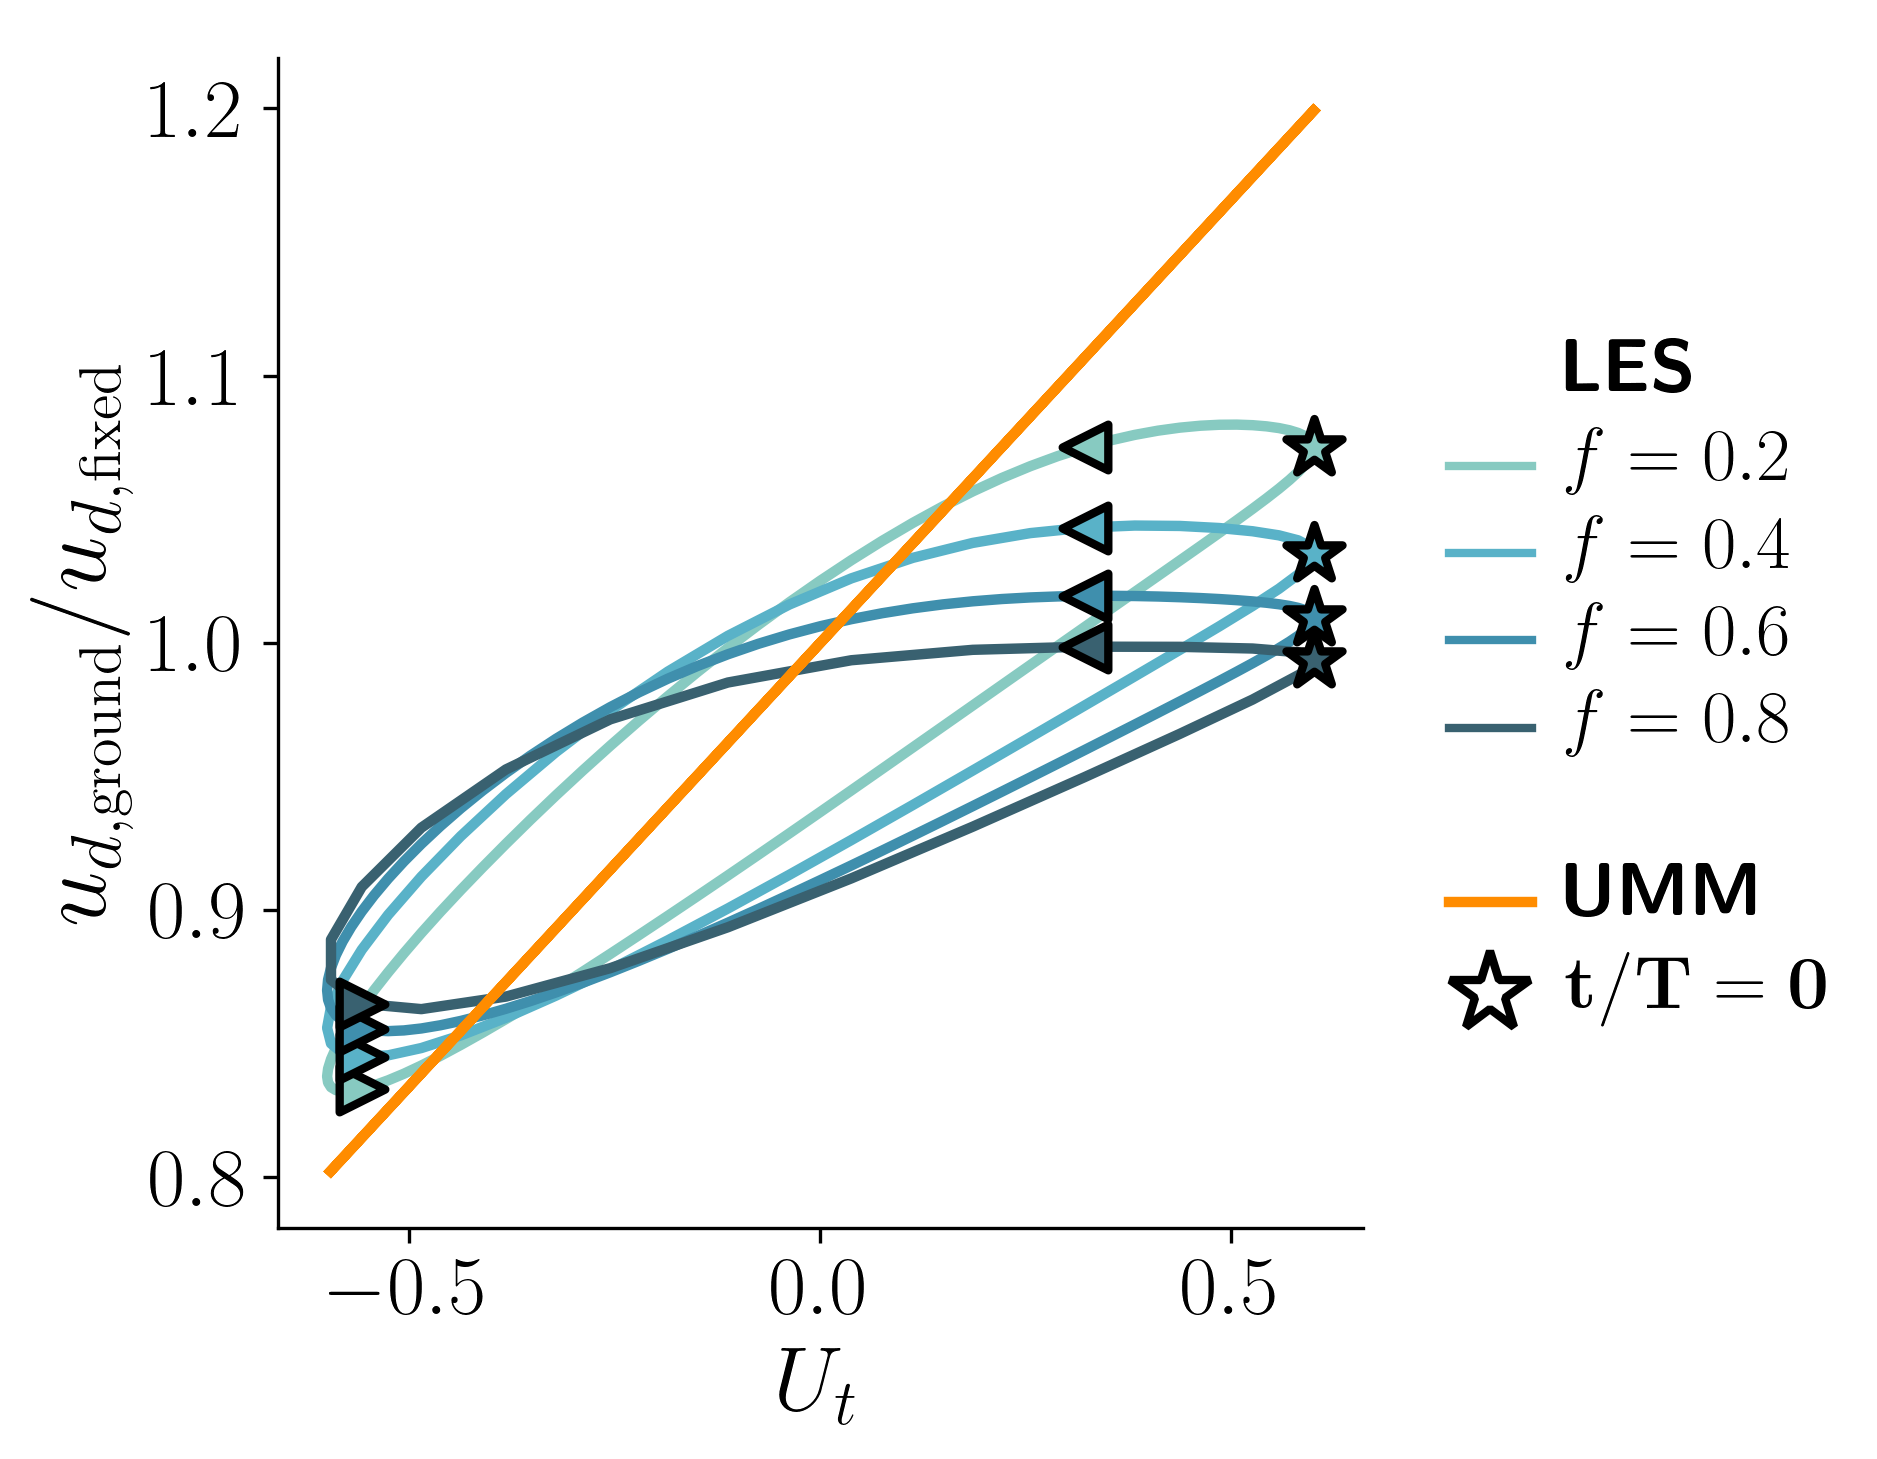

In [ ]:
# Create the relplot with columns based on "Local Thrust Velocity"
# Create the relplot
palette = sns.color_palette("GnBu_d", n_colors=len(freqs))

g = sns.relplot(
    data=sub_df_phase_avg_les_surge[sub_df_phase_avg_les_surge["Amplitude"] == 0.6],
    x="UTurb",
    y="UDisk_Ground_Normalized",
    hue="Frequency",
    palette=palette,
    linewidth=2.5,
    kind="line",
    col="Amplitude",
    height=4,
    aspect=1.2,
    facet_kws={"sharey": True, "sharex": True},
    sort=False,
)

# === Add ARROWS for Phase = 0.25 and Phase = 0.75 ===
for (amp, ax) in g.axes_dict.items():

    # rows for this amplitude
    dfA = sub_df_phase_avg_les_surge[
        (sub_df_phase_avg_les_surge["Amplitude"] == amp)
    ]

    # phase = 0 and 0.5 rows
    df0  = dfA[dfA["Phase_Rounded"] == 0]
    df1  = dfA[dfA["Phase_Rounded"] == 0.16]
    df2 = dfA[dfA["Phase_Rounded"] == 0.56]

    # Loop through frequency groups so we can color arrows by frequency
    for freq, df_f in df0.groupby("Frequency"):
        color = palette[list(sorted(dfA["Frequency"].unique())).index(freq)]

        ax.scatter(
            df_f["UTurb"],
            df_f["UDisk_Ground_Normalized"],
            marker="*",
            s=200,
            facecolors=color,
            edgecolors="k",
            linewidth=2,
            zorder=25
        )

    for freq, df_f in df1.groupby("Frequency"):
        color = palette[list(sorted(dfA["Frequency"].unique())).index(freq)]

        ax.scatter(
            df_f["UTurb"],
            df_f["UDisk_Ground_Normalized"],
            marker="<",
            s=120,
            facecolors=color, 
            edgecolors="k",
            linewidth=2,
            zorder=25
        )

    for freq, df_f in df2.groupby("Frequency"):
        color = palette[list(sorted(dfA["Frequency"].unique())).index(freq)]

        ax.scatter(
            df_f["UTurb"],
            df_f["UDisk_Ground_Normalized"],
            marker=">",
            s=120,
            facecolors=color,
            edgecolors="k",
            linewidth=2,
            zorder=25
        )
g.fig.set_size_inches(5, 5)
g.fig.set_dpi(300)
g._legend.remove()

# # Add the UMM horizontal line to each axis
for (i, ax) in enumerate(g.axes.flatten()):
    if i == 0:
        vals = sub_df_umm_surge[(sub_df_umm_surge["Amplitude"] == 0.6)]
    else:
        vals = sub_df_umm_surge[(sub_df_umm_surge["Amplitude"] == 0.8)]
    vals = vals.sort_values(by = ["Phase_Rounded"])
    ax.plot(vals["UTurb"], vals["UDisk_Ground_Normalized"], c="darkorange", linewidth=2.5)
    

# ====== Custom legend ======
# # LES subheaders: Amplitude and Frequency
les_header = Line2D([], [], linestyle="none", marker="", label="\\textbf{LES}", color="none")

# # LES handles (line styles for frequencies)
freqs = sorted(df_phase_avg_les_surge["Frequency"].unique())
freq_handles = [Line2D([], [], color=palette[i], lw=2, label=f"$f = {freqs[i]}$") for i in range(len(freqs))]

# # UMM line handle
umm_header = Line2D([], [], color="darkorange", linewidth=2.5, label="\\textbf{UMM}")

# Star marker for t/T = 0
star_handle = Line2D(
    [], [], 
    marker="*", 
    markersize=20,
    markerfacecolor="white",
    markeredgecolor="k",
    linewidth=0,
    markeredgewidth=2,
    label="$\mathbf{t/T = 0}$"
)

# # Combine all handles
all_handles = [les_header] + freq_handles + [space_header, umm_header, star_handle]

# # Place the legend outside the plot (right)
leg = g.fig.legend(
    handles=all_handles,
    # title="Frequency",
    loc="center right",
    bbox_to_anchor=(1.2, 0.5),
    bbox_transform=g.fig.transFigure,
    frameon = False
)

# # Style legend
leg.get_title().set_fontsize(label_size)
leg.get_title().set_fontweight("bold")
for text in leg.get_texts():
    text.set_fontsize(label_size - 4)

# # Set labels and title for the whole figure
g.set_titles(" ", size=0)
for ax in g.axes.flatten():
    ax.set_xlabel("$U_t$", fontsize=label_size)
    ax.set_ylabel("$u_{d,\\textrm{\\fontsize{14}{14}\\selectfont ground}} /  u_{d,\\textrm{\\fontsize{14}{14}\\selectfont fixed}}$", fontsize=label_size + 2)
    ax.tick_params(axis="both", labelsize=label_size - 2)
    ax.tick_params(axis="y", labelsize=label_size - 2)

# g.fig.suptitle("Normalized Disk Velocity in the Ground Frame", fontsize=title_size)
# g.fig.tight_layout()
# g.fig.subplots_adjust(top=0.9)  # leave space for suptitle

In [ ]:
f = 0.4
uturb, dx = get_uturb_vals(0.2, f, 0.05)
uinf_vals = np.ones_like(uturb)
uinf_t = 1 - uturb
model_vals = model(1.33, yaw = 0.0, tilt = 0.0)
xvals = np.arange(0, 1/f , dt)

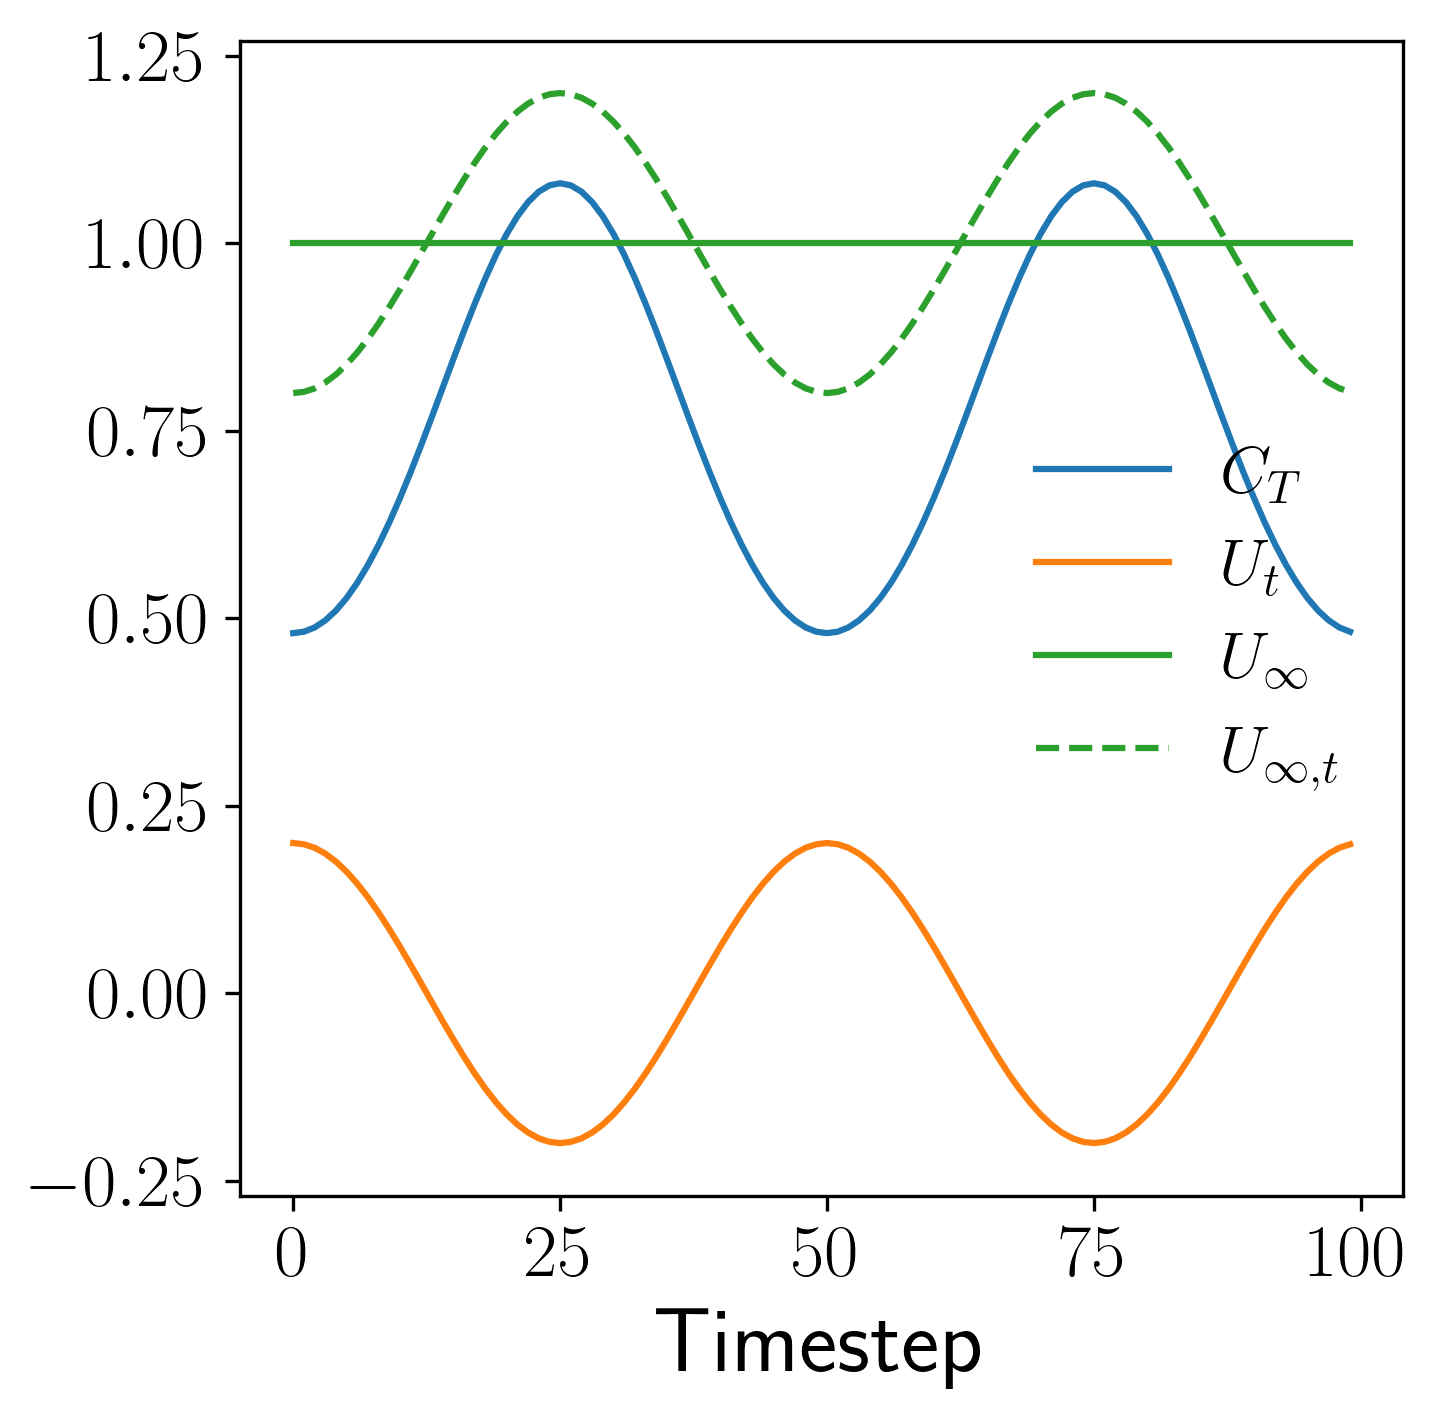

In [ ]:
fig, ax = plt.subplots(figsize=(6,4))

xvals = range(0, len(uturb))

sns.lineplot(ax=ax, x=xvals, y=model_vals.Ct * uinf_t**2, label="$C_T$")
sns.lineplot(ax=ax, x=xvals, y=uturb, label="$U_t$")
sns.lineplot(ax=ax, x=xvals, y=uinf, label="$U_{\infty}$", color="tab:green")
sns.lineplot(ax=ax, x=xvals, y=uinf_t, label="$U_{\infty, t}$", color="tab:green", linestyle="--")

# Axis labels
ax.set_xlabel("Timestep", fontsize=label_size)

# Tick sizes
ax.tick_params(axis="both", labelsize=18)

# Legend
leg = ax.legend(frameon=False, fontsize=16)
for text in leg.get_texts():
    text.set_fontsize(16)

fig.set_size_inches(5, 5)
fig.set_dpi(300)